# Part 1: Environment Setup and Initial Data Preparation- שלב טעינה והכנה בסיסית

## Research question

**How do property and location characteristics affect the price per square meter in Tel Aviv?**

This section prepares the working environment, loads the real-estate transaction dataset, standardizes the variable names, and creates the main variables required for the analysis.

The original data are preserved in a separate DataFrame before any transformations are applied. No observations are removed at this stage.

Two important derived variables are created:

1. `price_per_sqm`: the transaction amount divided by the property area.
2. `is_preconstruction`: an indicator identifying transactions in which the recorded construction year is later than the transaction year.

A negative building age is therefore not automatically treated as an error or converted into a missing value. Such a transaction may represent a property purchased before construction was completed.

In [14]:
# ============================================
# Part 1: Environment setup and data loading
# ============================================

from pathlib import Path

import numpy as np
import pandas as pd


# --------------------------------------------
# 1. Locate the input file
# --------------------------------------------

file_name = "tel_aviv_real_estate.xlsx"

possible_paths = [
    Path(file_name),
    Path.cwd() / file_name,
    Path("/content") / file_name
]

file_path = next(
    (path for path in possible_paths if path.exists()),
    None
)

# If the file is not found and the notebook runs in Google Colab,
# the user is asked to upload it.
if file_path is None:
    try:
        from google.colab import files

        print(f"Please upload: {file_name}")
        uploaded_files = files.upload()

        if file_name not in uploaded_files:
            raise FileNotFoundError(
                f"The uploaded files do not include '{file_name}'."
            )

        file_path = Path("/content") / file_name

    except ImportError as error:
        raise FileNotFoundError(
            f"Could not find '{file_name}'. "
            "Place the file in the same folder as the notebook."
        ) from error


# --------------------------------------------
# 2. Load the dataset
# --------------------------------------------

df_raw = pd.read_excel(file_path)

# Create a separate working copy so the original data remain unchanged.
df = df_raw.copy()


# --------------------------------------------
# 3. Standardize column names
# --------------------------------------------

column_name_mapping = {
    "OBJECTID": "transaction_id",
    "Deals_DealDate": "transaction_date",
    "Deals_DealAmount": "transaction_amount",
    "Deals_YearBuilt": "year_built",
    "Assets_BuildingFloors": "building_floors",
    "Assets_SettlmentID": "settlement_id",
    "Assets_SettlementNameHeb": "settlement_name_hebrew",
    "Assets_SettlementNameEng": "settlement_name_english",
    "Assets_FloorNo": "floor_description",
    "Assets_AssetArea": "property_area_sqm",
    "Assets_X_RECOMMENDED": "x_coordinate",
    "Assets_Y_RECOMMENDED": "y_coordinate",
    "HUJIUnite": "spatial_unit_id"
}

df = df.rename(columns=column_name_mapping)


# --------------------------------------------
# 4. Convert variables to suitable data types
# --------------------------------------------

numeric_columns = [
    "transaction_amount",
    "year_built",
    "building_floors",
    "settlement_id",
    "property_area_sqm",
    "x_coordinate",
    "y_coordinate",
    "spatial_unit_id"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

df["transaction_date"] = pd.to_datetime(
    df["transaction_date"],
    errors="coerce"
)

df["transaction_year"] = df["transaction_date"].dt.year.astype("Int64")


# --------------------------------------------
# 5. Create variables required for the analysis
# --------------------------------------------

# Calculate the unadjusted age of the building at the transaction date.
# Negative values are preserved because they may represent
# purchases made before construction was completed.
df["building_age_raw"] = (
    df["transaction_year"] - df["year_built"]
).astype("Float64")

# Identify transactions recorded before the construction year.
df["is_preconstruction"] = (
    df["year_built"].notna()
    & df["transaction_year"].notna()
    & (df["year_built"] > df["transaction_year"])
).astype("int8")

# Calculate price per square meter only when both inputs are positive.
valid_price_area = (
    df["transaction_amount"].gt(0)
    & df["property_area_sqm"].gt(0)
)

df["price_per_sqm"] = np.where(
    valid_price_area,
    df["transaction_amount"] / df["property_area_sqm"],
    np.nan
)


# --------------------------------------------
# 6. Define basic project objects
# --------------------------------------------

# List: variables expected to be central to the research question.
analysis_variables = [
    "price_per_sqm",
    "property_area_sqm",
    "building_age_raw",
    "building_floors",
    "floor_description",
    "is_preconstruction",
    "x_coordinate",
    "y_coordinate"
]

# Dictionary: coordinate reference systems used in the project.
coordinate_reference_systems = {
    "source_crs": "EPSG:2039",
    "geographic_crs": "EPSG:4326"
}

# Tuple: expected transaction-year range in the original dataset.
expected_year_range = (2012, 2017)

# Two-dimensional NumPy array containing the projected coordinates.
coordinate_matrix = df[
    ["x_coordinate", "y_coordinate"]
].to_numpy()


# --------------------------------------------
# 7. Initial validation
# --------------------------------------------

required_columns = set(column_name_mapping.values())
missing_required_columns = required_columns.difference(df.columns)

if missing_required_columns:
    raise ValueError(
        "The following required columns are missing: "
        f"{sorted(missing_required_columns)}"
    )

if df.empty:
    raise ValueError("The dataset was loaded but contains no records.")


# --------------------------------------------
# 8. Display an initial overview
# --------------------------------------------

print("File loaded successfully.")
print(f"File path: {file_path}")
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]:,}")
print(f"Original data preserved: {df_raw.shape == df_raw.copy().shape}")
print(f"Coordinate matrix shape: {coordinate_matrix.shape}")
print(f"Pre-construction transactions: {df['is_preconstruction'].sum():,}")
print()

print("Transaction-year range:")
print(df["transaction_year"].agg(["min", "max"]))
print()

print("Missing values in selected variables:")
print(
    df[
        [
            "transaction_date",
            "transaction_amount",
            "year_built",
            "building_floors",
            "floor_description",
            "property_area_sqm",
            "x_coordinate",
            "y_coordinate",
            "price_per_sqm"
        ]
    ]
    .isna()
    .sum()
    .sort_values(ascending=False)
)
print()

display(df.head())

File loaded successfully.
File path: tel_aviv_real_estate.xlsx
Number of rows: 37,358
Number of columns: 17
Original data preserved: True
Coordinate matrix shape: (37358, 2)
Pre-construction transactions: 1,518

Transaction-year range:
min    2012
max    2017
Name: transaction_year, dtype: int64

Missing values in selected variables:
floor_description     11698
building_floors       11553
year_built             2702
price_per_sqm           845
property_area_sqm       845
transaction_date          0
transaction_amount        0
x_coordinate              0
y_coordinate              0
dtype: int64



,transaction_id,transaction_date,transaction_amount,year_built,building_floors,settlement_id,settlement_name_hebrew,settlement_name_english,floor_description,property_area_sqm,x_coordinate,y_coordinate,spatial_unit_id,transaction_year,building_age_raw,is_preconstruction,price_per_sqm
0,1,2013-04-29,1100000,1977.0,4.0,5000,תל אביב -יפו,TEL AVIV - YAFO,שניה,81.26,176488.0000,659754.0000,50000736,2013,36.0,0,13536.795471
1,2,2016-02-23,1040000,1976.0,4.0,5000,תל אביב -יפו,TEL AVIV - YAFO,ראשונה,76.97,176512.0000,659755.0000,50000736,2016,40.0,0,13511.757828
2,3,2014-12-04,378700,1960.0,4.0,5000,תל אביב -יפו,TEL AVIV - YAFO,שניה,61.46,176465.8868,659765.2835,50000736,2014,54.0,0,6161.731207
3,4,2014-02-24,950000,1970.0,4.0,5000,תל אביב -יפו,TEL AVIV - YAFO,ראשונה,64.90,176502.0882,659782.1090,50000736,2014,44.0,0,14637.904468
4,5,2017-05-10,1300000,1970.0,4.0,5000,תל אביב -יפו,TEL AVIV - YAFO,שניה,76.52,176502.0882,659782.1090,50000736,2017,47.0,0,16989.022478


# Part 2: Cleaning and Parsing Floor Descriptions

The original floor field contains many inconsistent Hebrew descriptions. These include standard floors, basements, ground floors, roof levels, mezzanines, yards, storage areas, and properties occupying several levels.

The original description is preserved. A standardized text version is then created and used to extract several variables:

- `lowest_floor`: the lowest identifiable floor.
- `highest_floor`: the highest identifiable floor.
- `property_floor_count`: the number of distinct identifiable floor levels.
- `is_multilevel`: whether the property occupies more than one identifiable floor.
- Indicators for basement, ground floor, roof, mezzanine, yard, columns, storage, and commercial descriptions.
- `floor_parse_status`: whether the description was fully parsed, partially parsed, missing, or ambiguous.

A single floor number is not imposed on multi-level properties. Ambiguous descriptions are retained and marked rather than assigned an artificial numerical value.

In [15]:
# ============================================
# Part 2: Cleaning and parsing floor descriptions
# ============================================

import re
import unicodedata


# --------------------------------------------
# 1. Define floor terminology
# --------------------------------------------

# Regular Hebrew floor names and their numerical values.
floor_word_mapping = {
    "ראשונה": 1,
    "ראשנה": 1,
    "שניה": 2,
    "שנייה": 2,
    "שלישית": 3,
    "שליש": 3,
    "רביעית": 4,
    "חמישית": 5,
    "שישית": 6,
    "ששית": 6,
    "שביעית": 7,
    "שמינית": 8,
    "תשיעית": 9,
    "עשירית": 10,
    "אחת עשרה": 11,
    "שתים עשרה": 12,
    "שתיים עשרה": 12,
    "שלוש עשרה": 13,
    "שלש עשרה": 13,
    "ארבע עשרה": 14,
    "חמש עשרה": 15,
    "שש עשרה": 16,
    "שבע עשרה": 17,
    "שמונה עשרה": 18,
    "תשע עשרה": 19,
    "עשרים": 20,
    "עשרים ואחת": 21,
    "עשרים ושתיים": 22,
    "עשרים ושתים": 22,
    "עשרים ושלוש": 23,
    "עשרים וארבע": 24,
    "עשרים וחמש": 25,
    "עשרים ושש": 26,
    "עשרים ושבע": 27,
    "עשרים ושמונה": 28,
    "עשרים ותשע": 29,
    "שלושים": 30,
    "שלושים ואחת": 31,
    "שלושים ושתיים": 32,
    "שלושים ושתים": 32,
    "שלושים ושלוש": 33,
    "שלושים וארבע": 34,
    "שלושים וחמש": 35,
    "שלושים ושש": 36,
    "שלושים ושבע": 37,
    "שלושים ושמונה": 38,
    "שלושים ותשע": 39,
    "ארבעים": 40,
    "ארבעים ואחת": 41,
    "ארבעים ושתיים": 42,
    "ארבעים ושלוש": 43,
    "ארבעים וארבע": 44,
    "ארבעים וחמש": 45,
    "ארבעים ושש": 46
}

# Hebrew letter abbreviations sometimes used for floor numbers.
hebrew_letter_mapping = {
    "א": 1,
    "ב": 2,
    "ג": 3,
    "ד": 4,
    "ה": 5
}

# Values that do not provide a usable floor description.
ambiguous_floor_patterns = [
    "ראה הערת רשם",
    "ראה הערות רשם",
    "ראה הערות",
    "ראה בהערות"
]


# --------------------------------------------
# 2. Create text-cleaning functions
# --------------------------------------------

def normalize_floor_text(value):
    """
    Standardize a floor description while preserving its meaning.
    Missing and unusable descriptions are returned as missing values.
    """

    if pd.isna(value):
        return pd.NA

    text = unicodedata.normalize("NFKC", str(value)).strip()

    # Treat strings containing only dashes, spaces, or parentheses as missing.
    if re.fullmatch(r"[\s\-\(\)]+", text):
        return pd.NA

    # Standardize punctuation and common separators.
    text = text.replace("־", "-")
    text = text.replace("/", ",")
    text = text.replace("+", ",")
    text = text.replace(";", ",")
    text = text.replace(".", ",")
    text = re.sub(r"\s*-\s*", " ", text)
    text = re.sub(r"\s*,\s*", ",", text)
    text = re.sub(r"\s+", " ", text)

    # Correct several recurring spelling variations.
    spelling_replacements = {
        "ראשנה": "ראשונה",
        "שנייה": "שניה",
        "בניים": "ביניים",
        "בינים": "ביניים",
        "הביינים": "ביניים",
        "קומת ביניים": "ביניים",
        "ק.ביניים": "ביניים",
        "ק. ביניים": "ביניים",
        "קומת גג": "גג",
        "ק.גג": "גג",
        "ק. גג": "גג",
        "הגג": "גג",
        "קומת עמודים": "עמודים",
        "החנויות": "חנויות"
    }

    for old_text, new_text in spelling_replacements.items():
        text = text.replace(old_text, new_text)

    return text.strip(" ,")


def extract_floor_numbers(clean_text):
    """
    Extract all identifiable numerical floor levels from a cleaned description.

    Coding decisions:
    - Basement is coded as -1.
    - Ground floor is coded as 0.
    - Regular floors are coded as positive integers.
    - Special non-numerical levels are represented by separate indicators.
    """

    if pd.isna(clean_text):
        return []

    text = str(clean_text)
    detected_floors = []

    # Basement and ground are meaningful numerical levels.
    if "מרתף" in text or "מסד" in text:
        detected_floors.append(-1)

    if "קרקע" in text:
        detected_floors.append(0)

    # Search longer phrases before shorter phrases to avoid partial matches.
    sorted_floor_words = sorted(
        floor_word_mapping.items(),
        key=lambda item: len(item[0]),
        reverse=True
    )

    matched_text = text

    for floor_word, floor_number in sorted_floor_words:
        if floor_word in matched_text:
            detected_floors.append(floor_number)
            matched_text = matched_text.replace(floor_word, " ")

    # Extract standalone Arabic numerals, while excluding decimal measurements.
    digit_matches = re.findall(r"(?<![\d.])\d{1,2}(?![\d.])", matched_text)

    for digit in digit_matches:
        number = int(digit)

        # Values above 50 are treated as suspicious codes rather than floors.
        if 0 <= number <= 50:
            detected_floors.append(number)

    # Extract standalone Hebrew floor-letter abbreviations.
    letter_matches = re.findall(
        r"(?:^|[\s,])([אבגדה])['״]?(?=$|[\s,])",
        matched_text
    )

    for letter in letter_matches:
        detected_floors.append(hebrew_letter_mapping[letter])

    # Return distinct floors in ascending order.
    return sorted(set(detected_floors))


def classify_floor_parse_status(clean_text, extracted_floors):
    """
    Describe the quality of the numerical floor extraction.
    """

    if pd.isna(clean_text):
        return "missing"

    text = str(clean_text)

    if any(pattern in text for pattern in ambiguous_floor_patterns):
        return "ambiguous"

    special_terms = [
        "גג",
        "ביניים",
        "גלריה",
        "יציע",
        "חצר",
        "עמודים",
        "מפולשת",
        "מחסן",
        "חנויות",
        "חניה",
        "חדר מכונות"
    ]

    contains_special_term = any(term in text for term in special_terms)

    if extracted_floors and contains_special_term:
        return "partially_parsed"

    if extracted_floors:
        return "parsed"

    if contains_special_term:
        return "special_only"

    return "ambiguous"


# --------------------------------------------
# 3. Preserve and standardize the descriptions
# --------------------------------------------

df["floor_description_original"] = df["floor_description"]

df["floor_description_clean"] = df[
    "floor_description_original"
].apply(normalize_floor_text)


# --------------------------------------------
# 4. Extract numerical floor information
# --------------------------------------------

df["identified_floors"] = df[
    "floor_description_clean"
].apply(extract_floor_numbers)

# Count only the numerically identified floors at this stage.
df["identified_floor_count"] = df[
    "identified_floors"
].apply(len).astype("Int64")

df["lowest_floor"] = df["identified_floors"].apply(
    lambda floors: min(floors) if floors else np.nan
)

df["highest_floor"] = df["identified_floors"].apply(
    lambda floors: max(floors) if floors else np.nan
)

df["lowest_floor"] = pd.to_numeric(
    df["lowest_floor"],
    errors="coerce"
).astype("Float64")

df["highest_floor"] = pd.to_numeric(
    df["highest_floor"],
    errors="coerce"
).astype("Float64")


# --------------------------------------------
# 5. Create indicators for special characteristics
# --------------------------------------------

special_floor_terms = {
    "has_basement": ["מרתף", "מסד"],
    "has_ground_floor": ["קרקע"],
    "has_roof_level": ["גג"],
    "has_mezzanine": ["ביניים", "גלריה", "יציע"],
    "has_yard": ["חצר"],
    "has_columns_level": ["עמודים", "מפולשת"],
    "has_storage": ["מחסן", "מחסנים"],
    "is_shop_description": ["חנות", "חנויות"],
    "is_parking_description": ["חניה", "חניות"],
    "has_machine_room": ["חדר מכונות"]
}

for new_column, search_terms in special_floor_terms.items():
    df[new_column] = df["floor_description_clean"].apply(
        lambda text: int(
            pd.notna(text)
            and any(term in str(text) for term in search_terms)
        )
    ).astype("int8")
# --------------------------------------------
# 6. Calculate the total number of property levels
# --------------------------------------------

# Roof levels and mezzanine/gallery levels are counted as additional
# property levels because they may form part of a multi-level property.
#
# Yard, storage, parking, and columns descriptions are not automatically
# counted as additional levels.
df["special_level_count"] = (
    df["has_roof_level"]
    + df["has_mezzanine"]
).astype("Int64")

df["property_floor_count"] = (
    df["identified_floor_count"]
    + df["special_level_count"]
).astype("Int64")

df["is_multilevel"] = (
    df["property_floor_count"] > 1
).astype("int8")

# --------------------------------------------
# 6. Describe the extraction quality
# --------------------------------------------

df["floor_parse_status"] = [
    classify_floor_parse_status(clean_text, floors)
    for clean_text, floors in zip(
        df["floor_description_clean"],
        df["identified_floors"]
    )
]


# --------------------------------------------
# 7. Create a simplified analytical category
# --------------------------------------------

def create_floor_category(row):
    """
    Create one broad category for descriptive summaries and categorical charts.
    The detailed indicator variables remain available separately.
    """

    if row["floor_parse_status"] == "missing":
        return "missing"

    if row["floor_parse_status"] == "ambiguous":
        return "ambiguous"

    if row["is_shop_description"] == 1:
        return "shop"

    if row["is_parking_description"] == 1:
        return "parking"

    if row["is_multilevel"] == 1:
        return "multilevel"

    if row["has_basement"] == 1:
        return "basement"

    if row["has_ground_floor"] == 1:
        return "ground"

    if row["has_roof_level"] == 1:
        return "roof_or_top_level"

    if row["has_mezzanine"] == 1:
        return "mezzanine_or_gallery"

    if pd.notna(row["lowest_floor"]):
        return "regular_floor"

    return "other_special"


df["floor_category"] = df.apply(
    create_floor_category,
    axis=1
).astype("category")


# --------------------------------------------
# 8. Validate the new variables
# --------------------------------------------

# The lowest floor must not be above the highest floor.
invalid_floor_range = (
    df["lowest_floor"].notna()
    & df["highest_floor"].notna()
    & (df["lowest_floor"] > df["highest_floor"])
)

if invalid_floor_range.any():
    raise ValueError(
        "At least one record has a lowest floor above its highest floor."
    )

# A multi-level property must contain at least two identified levels.
invalid_multilevel = (
    (df["is_multilevel"] == 1)
    & (df["property_floor_count"] < 2)
)

if invalid_multilevel.any():
    raise ValueError(
        "The multi-level indicator is inconsistent with the floor count."
    )


# --------------------------------------------
# 9. Display parsing results
# --------------------------------------------

print("Floor descriptions were processed successfully.")
print()

print("Floor parsing status:")
print(df["floor_parse_status"].value_counts(dropna=False))
print()

print("Simplified floor categories:")
print(df["floor_category"].value_counts(dropna=False))
print()

print(
    "Multi-level properties:",
    f"{df['is_multilevel'].sum():,}"
)
print(
    "Properties including a basement:",
    f"{df['has_basement'].sum():,}"
)
print(
    "Properties including a roof level:",
    f"{df['has_roof_level'].sum():,}"
)
print()

# Display examples of complex descriptions and their extracted information.
complex_floor_examples = df.loc[
    df["is_multilevel"].eq(1)
    | df["floor_parse_status"].isin(
        ["partially_parsed", "special_only", "ambiguous"]
    ),
    [
        "floor_description_original",
        "floor_description_clean",
        "identified_floors",
        "lowest_floor",
        "highest_floor",
        "property_floor_count",
        "is_multilevel",
        "floor_category",
        "floor_parse_status"
    ]
].copy()

# Convert the list temporarily to a tuple so duplicate rows can be identified.
complex_floor_examples["identified_floors"] = (
    complex_floor_examples["identified_floors"].apply(tuple)
)

complex_floor_examples = (
    complex_floor_examples
    .drop_duplicates()
    .head(30)
)

display(complex_floor_examples)

Floor descriptions were processed successfully.

Floor parsing status:
floor_parse_status
parsed              24827
missing             11905
special_only          308
partially_parsed      294
ambiguous              24
Name: count, dtype: int64

Simplified floor categories:
floor_category
regular_floor           21771
missing                 11905
ground                   1982
multilevel               1002
basement                  366
roof_or_top_level         100
other_special              95
mezzanine_or_gallery       88
ambiguous                  24
shop                       24
parking                     1
Name: count, dtype: int64

Multi-level properties: 1,002
Properties including a basement: 598
Properties including a roof level: 340



,floor_description_original,floor_description_clean,identified_floors,lowest_floor,highest_floor,property_floor_count,is_multilevel,floor_category,floor_parse_status
246,שניה+שלישית,"שניה,שלישית","(2, 3)",2.0,3.0,2,1,multilevel,parsed
290,רביעית+חמישית,"רביעית,חמישית","(4, 5)",4.0,5.0,2,1,multilevel,parsed
297,רביעית + חמישית,"רביעית,חמישית","(4, 5)",4.0,5.0,2,1,multilevel,parsed
299,שניה שלישית,שניה שלישית,"(2, 3)",2.0,3.0,2,1,multilevel,parsed
301,שניה ושלישית,שניה ושלישית,"(2, 3)",2.0,3.0,2,1,multilevel,parsed
327,קרקע + ראשונה,"קרקע,ראשונה","(0, 1)",0.0,1.0,2,1,multilevel,parsed
781,רביעית וחמישית,רביעית וחמישית,"(4, 5)",4.0,5.0,2,1,multilevel,parsed
870,קרקע גלריה,קרקע גלריה,"(0,)",0.0,0.0,2,1,multilevel,partially_parsed
1142,קרקע+גג,"קרקע,גג","(0,)",0.0,0.0,2,1,multilevel,partially_parsed
1567,"מרתף,קרקע,גג","מרתף,קרקע,גג","(-1, 0)",-1.0,0.0,3,1,multilevel,partially_parsed


# Part 3: Data Quality Assessment and Analytical Sample

This section constructs the analytical sample used in the remainder of the project.

The original working DataFrame is preserved. Records are not deleted from `df`; instead, a separate DataFrame named `analysis_df` is created.

The cleaning process includes:

- Excluding records identified as shops or parking transactions, because the research focuses on residential apartments.
- Requiring valid transaction dates, positive transaction amounts, positive property areas, and valid coordinates.
- Preserving records with ambiguous floor descriptions, because an unclear floor description does not necessarily indicate a non-residential property.
- Preserving pre-construction transactions and representing them with a separate indicator.
- Flagging possible duplicate transactions without removing them automatically.
- Creating a logarithmic transformation of price per square meter to reduce the influence of highly extreme values without deleting valid transactions.

The 1st and 99th percentiles are calculated only for diagnostic purposes. Transactions outside these thresholds are flagged, but they are not removed from the main analytical sample.

A separate sensitivity sample is also created so that later models can be compared with and without the extreme 1% tails.


בחלק זה נבנה מדגם הניתוח שישמש אותנו בהמשך הפרויקט.

מסגרת הנתונים המקורית נשמרת. הרשומות אינן נמחקות מתוך df; במקום זאת נוצרת מסגרת נתונים נפרדת בשם analysis_df.

תהליך הניקוי כולל:

הוצאה של רשומות שזוהו כחנויות או כעסקאות חניה, משום שהמחקר מתמקד בדירות מגורים.
דרישה לתאריך עסקה תקין, סכום עסקה חיובי, שטח נכס חיובי וקואורדינטות תקינות.
שמירה על רשומות שבהן תיאור הקומה עמום, משום שתיאור קומה לא ברור אינו מעיד בהכרח על נכס שאינו למגורים.
שמירה על עסקאות טרום־בנייה וייצוג שלהן באמצעות אינדיקטור נפרד.
סימון עסקאות שעשויות להיות כפולות, בלי להסיר אותן אוטומטית.
יצירת טרנספורמציה לוגריתמית של המחיר למ״ר, כדי לצמצם את השפעתם של ערכים קיצוניים מאוד בלי למחוק עסקאות תקינות.

האחוזונים 1 ו־99 מחושבים לצורכי אבחון בלבד. עסקאות שמחירן למ״ר נמצא מחוץ לספים האלה מסומנות, אך אינן מוסרות ממדגם הניתוח המרכזי.

בנוסף נוצר מדגם רגישות נפרד, כדי שבהמשך יהיה אפשר להשוות בין מודלים עם הערכים הקיצוניים ובלעדיהם.

In [16]:
# ============================================
# Part 3: Data quality and analytical sample
# ============================================


# --------------------------------------------
# 1. Preserve the data before analytical filters
# --------------------------------------------

df_before_cleaning = df.copy()


# --------------------------------------------
# 2. Identify non-residential records
# --------------------------------------------

# Shops and parking transactions are excluded because the research
# question focuses on residential apartments.
df["is_excluded_property_type"] = (
    df["is_shop_description"].eq(1)
    | df["is_parking_description"].eq(1)
).astype("int8")

excluded_property_type_count = int(
    df["is_excluded_property_type"].sum()
)

excluded_property_type_percentage = (
    excluded_property_type_count / len(df) * 100
)


# --------------------------------------------
# 3. Check essential transaction information
# --------------------------------------------

df["has_valid_date"] = (
    df["transaction_date"].notna()
).astype("int8")

df["has_valid_amount"] = (
    df["transaction_amount"].notna()
    & df["transaction_amount"].gt(0)
).astype("int8")

df["has_valid_area"] = (
    df["property_area_sqm"].notna()
    & df["property_area_sqm"].gt(0)
).astype("int8")

df["has_valid_coordinates"] = (
    df["x_coordinate"].notna()
    & df["y_coordinate"].notna()
    & df["x_coordinate"].gt(0)
    & df["y_coordinate"].gt(0)
).astype("int8")


# --------------------------------------------
# 4. Represent building age for later models
# --------------------------------------------

# A negative raw building age may represent a purchase made before
# construction was completed. Such records are not removed.
#
# For modeling purposes, their building age is set to zero, while the
# separate is_preconstruction indicator preserves this information.
df["building_age_for_model"] = np.where(
    df["is_preconstruction"].eq(1),
    0,
    df["building_age_raw"]
)

df["building_age_for_model"] = pd.to_numeric(
    df["building_age_for_model"],
    errors="coerce"
).astype("Float64")


# --------------------------------------------
# 5. Flag possible duplicate transactions
# --------------------------------------------

duplicate_check_columns = [
    "transaction_date",
    "transaction_amount",
    "property_area_sqm",
    "year_built",
    "floor_description_original",
    "x_coordinate",
    "y_coordinate"
]

df["is_possible_duplicate"] = df.duplicated(
    subset=duplicate_check_columns,
    keep=False
).astype("int8")

# Possible duplicates are flagged but not removed automatically,
# because similar transactions may represent different apartments
# in the same building.


# --------------------------------------------
# 6. Define the main residential sample
# --------------------------------------------

essential_record_condition = (
    df["is_excluded_property_type"].eq(0)
    & df["has_valid_date"].eq(1)
    & df["has_valid_amount"].eq(1)
    & df["has_valid_area"].eq(1)
    & df["has_valid_coordinates"].eq(1)
)

analysis_df = df.loc[
    essential_record_condition
].copy()

analysis_df = analysis_df.reset_index(drop=True)


# --------------------------------------------
# 7. Create a logarithmic price variable
# --------------------------------------------

# The logarithmic transformation reduces the influence of very high
# prices while preserving all valid residential transactions.
analysis_df["log_price_per_sqm"] = np.log(
    analysis_df["price_per_sqm"]
)


# --------------------------------------------
# 8. Calculate percentile thresholds for diagnostics
# --------------------------------------------

# These thresholds are used only to identify extreme observations.
# They do not determine which records are included in analysis_df.
price_per_sqm_percentiles = (
    analysis_df["price_per_sqm"]
    .quantile([0.01, 0.99])
)

price_per_sqm_lower_limit = float(
    price_per_sqm_percentiles.loc[0.01]
)

price_per_sqm_upper_limit = float(
    price_per_sqm_percentiles.loc[0.99]
)

analysis_df["is_price_per_sqm_extreme"] = (
    analysis_df["price_per_sqm"].lt(
        price_per_sqm_lower_limit
    )
    | analysis_df["price_per_sqm"].gt(
        price_per_sqm_upper_limit
    )
).astype("int8")


# --------------------------------------------
# 9. Create a sensitivity sample
# --------------------------------------------

# This additional sample excludes the lowest and highest 1% only for
# later robustness comparisons. It is not the main analytical sample.
sensitivity_df = analysis_df.loc[
    analysis_df["is_price_per_sqm_extreme"].eq(0)
].copy()

sensitivity_df = sensitivity_df.reset_index(drop=True)


# --------------------------------------------
# 10. Use NumPy statistical functions
# --------------------------------------------

price_per_sqm_array = analysis_df[
    "price_per_sqm"
].to_numpy(dtype=float)

log_price_per_sqm_array = analysis_df[
    "log_price_per_sqm"
].to_numpy(dtype=float)

numpy_price_statistics = {
    "price_mean": float(
        np.nanmean(price_per_sqm_array)
    ),
    "price_median": float(
        np.nanmedian(price_per_sqm_array)
    ),
    "price_standard_deviation": float(
        np.nanstd(price_per_sqm_array)
    ),
    "log_price_mean": float(
        np.nanmean(log_price_per_sqm_array)
    ),
    "log_price_median": float(
        np.nanmedian(log_price_per_sqm_array)
    ),
    "log_price_standard_deviation": float(
        np.nanstd(log_price_per_sqm_array)
    )
}


# --------------------------------------------
# 11. Create a cleaning summary
# --------------------------------------------

non_residential_condition = (
    df["is_excluded_property_type"].eq(1)
)

invalid_essential_condition = (
    df["is_excluded_property_type"].eq(0)
    & ~(
        df["has_valid_date"].eq(1)
        & df["has_valid_amount"].eq(1)
        & df["has_valid_area"].eq(1)
        & df["has_valid_coordinates"].eq(1)
    )
)

cleaning_summary = {
    "original_records": len(df),
    "excluded_shops_and_parking": int(
        non_residential_condition.sum()
    ),
    "invalid_or_missing_essential_information": int(
        invalid_essential_condition.sum()
    ),
    "main_analytical_records": len(analysis_df),
    "extreme_records_flagged": int(
        analysis_df["is_price_per_sqm_extreme"].sum()
    ),
    "sensitivity_sample_records": len(sensitivity_df),
    "preconstruction_records_in_main_sample": int(
        analysis_df["is_preconstruction"].sum()
    ),
    "possible_duplicates_in_main_sample": int(
        analysis_df["is_possible_duplicate"].sum()
    )
}


# --------------------------------------------
# 12. Validate the analytical sample
# --------------------------------------------

if analysis_df.empty:
    raise ValueError(
        "The analytical sample is empty after cleaning."
    )

if analysis_df["is_excluded_property_type"].any():
    raise ValueError(
        "The analytical sample still contains shops or parking records."
    )

if analysis_df["price_per_sqm"].isna().any():
    raise ValueError(
        "The analytical sample contains missing price-per-square-meter values."
    )

if analysis_df["log_price_per_sqm"].isna().any():
    raise ValueError(
        "The analytical sample contains missing logarithmic price values."
    )

if not np.isfinite(
    analysis_df["log_price_per_sqm"].to_numpy(dtype=float)
).all():
    raise ValueError(
        "The logarithmic price variable contains non-finite values."
    )


# --------------------------------------------
# 13. Display the cleaning results
# --------------------------------------------

print("The analytical sample was created successfully.")
print()

print("Excluded non-residential transactions:")
print(
    f"{excluded_property_type_count:,} records "
    f"({excluded_property_type_percentage:.6f}%)"
)
print()

print("Diagnostic price-per-square-meter thresholds:")
print(
    f"1st percentile: {price_per_sqm_lower_limit:,.2f}"
)
print(
    f"99th percentile: {price_per_sqm_upper_limit:,.2f}"
)
print()

print(
    "Important: records outside these thresholds were flagged, "
    "but were not removed from the main analytical sample."
)
print()

print("Cleaning summary:")
for description, value in cleaning_summary.items():
    print(f"{description}: {value:,}")

print()

print("NumPy price statistics:")
for statistic, value in numpy_price_statistics.items():
    print(f"{statistic}: {value:,.4f}")

print()

print("Lowest price-per-square-meter observations:")
display(
    analysis_df[
        [
            "transaction_id",
            "transaction_date",
            "transaction_amount",
            "property_area_sqm",
            "price_per_sqm",
            "log_price_per_sqm",
            "is_price_per_sqm_extreme"
        ]
    ]
    .sort_values("price_per_sqm")
    .head(10)
)

print("Highest price-per-square-meter observations:")
display(
    analysis_df[
        [
            "transaction_id",
            "transaction_date",
            "transaction_amount",
            "property_area_sqm",
            "price_per_sqm",
            "log_price_per_sqm",
            "is_price_per_sqm_extreme"
        ]
    ]
    .sort_values("price_per_sqm", ascending=False)
    .head(10)
)

The analytical sample was created successfully.

Excluded non-residential transactions:
25 records (0.066920%)

Diagnostic price-per-square-meter thresholds:
1st percentile: 1,141.07
99th percentile: 84,952.88

Important: records outside these thresholds were flagged, but were not removed from the main analytical sample.

Cleaning summary:
original_records: 37,358
excluded_shops_and_parking: 25
invalid_or_missing_essential_information: 838
main_analytical_records: 36,495
extreme_records_flagged: 730
sensitivity_sample_records: 35,765
preconstruction_records_in_main_sample: 1,509
possible_duplicates_in_main_sample: 0

NumPy price statistics:
price_mean: 28,687.0259
price_median: 26,881.7204
price_standard_deviation: 20,550.8120
log_price_mean: 10.0276
log_price_median: 10.1992
log_price_standard_deviation: 0.8395

Lowest price-per-square-meter observations:


,transaction_id,transaction_date,transaction_amount,property_area_sqm,price_per_sqm,log_price_per_sqm,is_price_per_sqm_extreme
7367,7471,2012-02-12,220000,47316.0,4.649590,1.536779,1
7377,7481,2012-07-23,250001,47316.0,5.283646,1.664616,1
8464,8611,2017-01-27,150000,21044.0,7.127922,1.964020,1
6411,6481,2013-05-02,250000,32660.0,7.654623,2.035310,1
7456,7561,2015-10-27,433333,47316.0,9.158276,2.214658,1
7379,7483,2012-07-25,450000,47316.0,9.510525,2.252399,1
36111,36971,2017-06-08,50000,5192.0,9.630200,2.264904,1
8893,9050,2017-01-26,150000,15000.0,10.000000,2.302585,1
6906,6987,2014-07-21,55000,5059.0,10.871714,2.386164,1
12730,13012,2016-02-28,650000,59258.0,10.968983,2.395072,1


Highest price-per-square-meter observations:


,transaction_id,transaction_date,transaction_amount,property_area_sqm,price_per_sqm,log_price_per_sqm,is_price_per_sqm_extreme
15790,16150,2013-12-22,198242450,125.0,1.585940e+06,14.276688,1
7217,7315,2016-06-15,29773000,25.0,1.190920e+06,13.990237,1
6989,7075,2015-08-30,9500000,25.0,3.800000e+05,12.847927,1
11557,11815,2012-03-19,8125000,24.0,3.385417e+05,12.732402,1
4611,4647,2017-03-31,7000000,21.0,3.333333e+05,12.716898,1
16126,16496,2015-05-31,36124332,110.0,3.284030e+05,12.701997,1
21159,21738,2012-12-23,18482760,57.6,3.208812e+05,12.678826,1
6988,7074,2015-06-10,8687500,28.0,3.102679e+05,12.645191,1
14235,14573,2014-04-22,6333300,21.0,3.015857e+05,12.616810,1
22565,23209,2013-03-31,26850000,95.0,2.826316e+05,12.551899,1


# Part 4: Descriptive Analysis and Data Visualization

This section examines the main characteristics of the residential transaction sample and presents the initial relationships between property characteristics and price per square meter.

The analysis includes:

- Descriptive statistics for transaction price, property area, price per square meter, building age, and floor characteristics.
- A comparison between the original price-per-square-meter distribution and its logarithmic transformation.
- A comparison of price per square meter across transaction years.
- A comparison of median price per square meter across floor categories.

The original observations are retained in the main analytical sample. The 99th percentile is used only to improve the readability of one histogram and does not remove records from the analysis.

All figures are saved as PNG files at a resolution of 150 dpi.

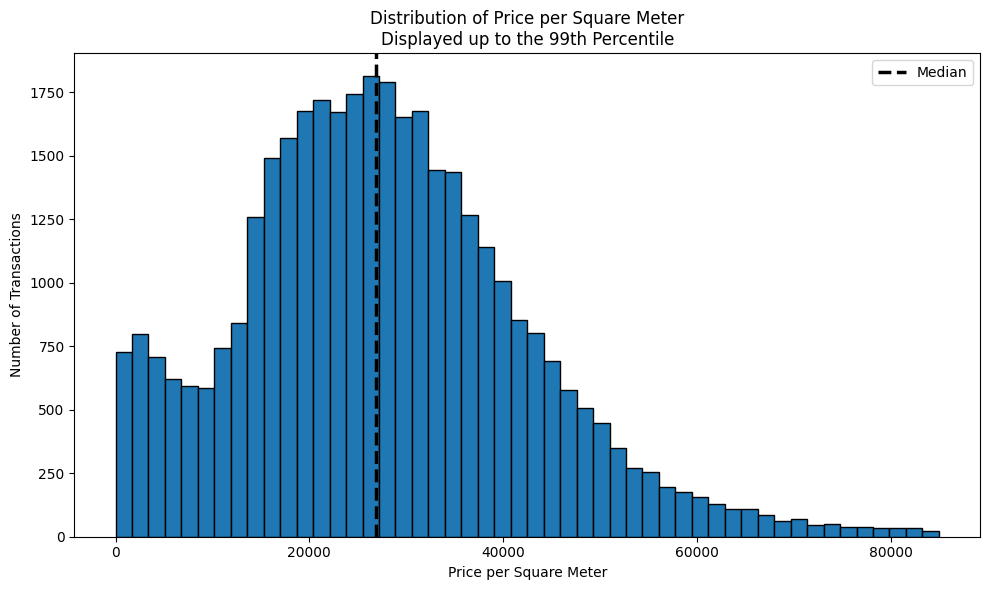

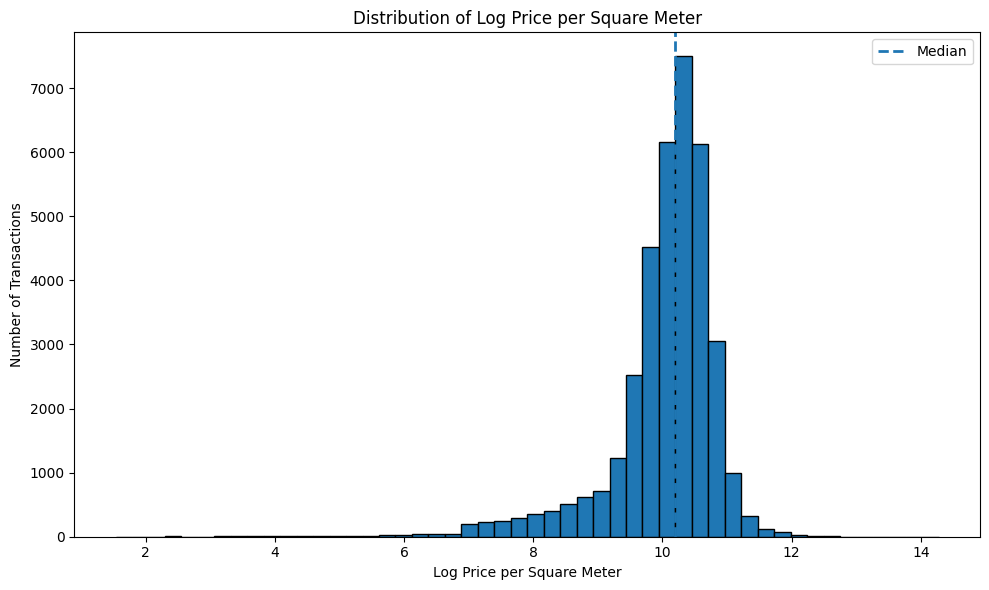

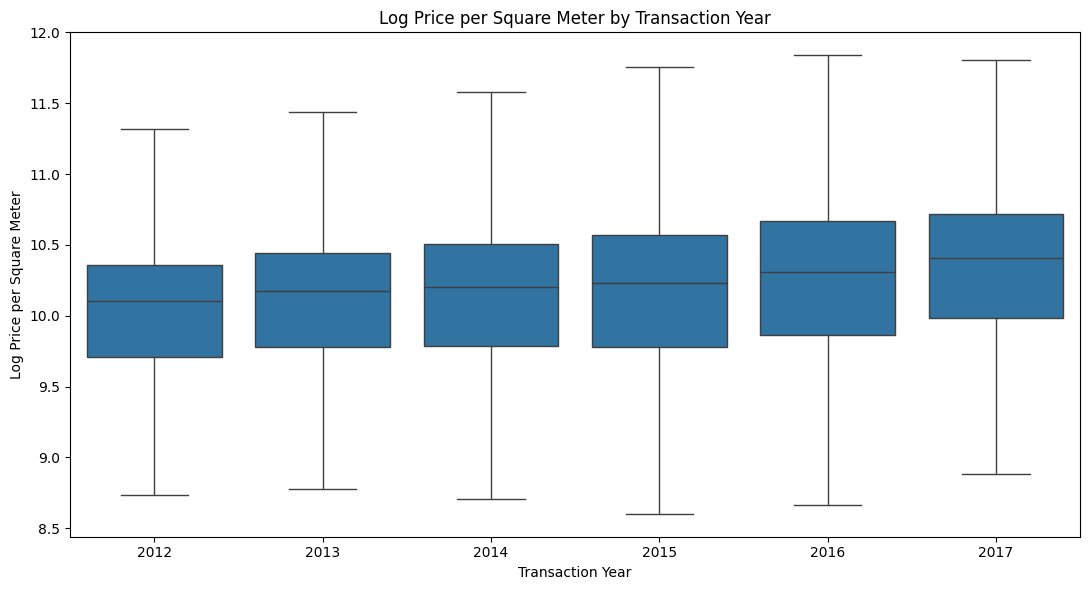

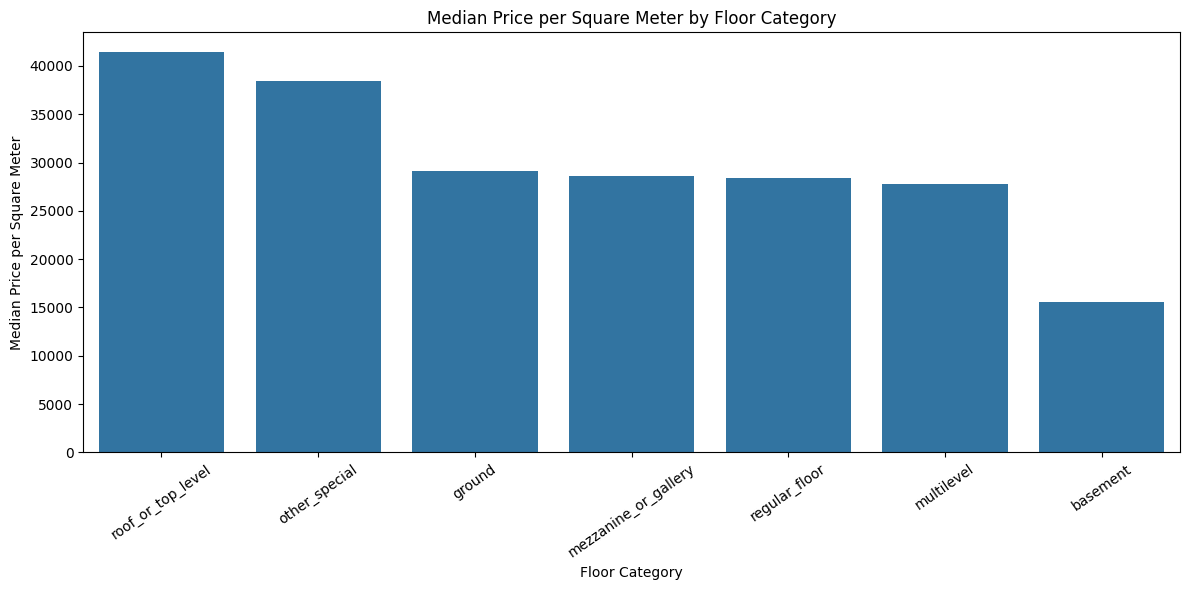

Descriptive analysis was completed successfully.

Figures saved in: /content/project_outputs/figures

Descriptive statistics:


,count,mean,std,min,1%,25%,50%,75%,99%,max,missing_values,missing_percentage
transaction_amount,36495.0,2614465.973065,3413872.035282,50000.0,145495.36,1380000.0,2120000.0,3119500.0,9370300.0,308801000.0,0,0.000000
property_area_sqm,36495.0,167.389363,964.192473,20.15,25.0,56.99,78.1,110.0,1592.0,59258.0,0,0.000000
price_per_sqm,36495.0,28687.025879,20551.09361,4.64959,1141.074126,17836.583224,26881.72043,36764.705882,84952.875773,1585939.6,0,0.000000
log_price_per_sqm,36495.0,10.02763,0.839524,1.536779,7.039725,9.789007,10.199202,10.512294,11.349852,14.276688,0,0.000000
building_age_for_model,33799.0,182.794609,525.230465,0.0,0.0,3.0,43.0,57.0,2016.0,2017.0,2696,7.387313
lowest_floor,24714.0,4.372866,6.143844,-1.0,-1.0,1.0,3.0,5.0,34.0,46.0,11781,32.281134
highest_floor,24714.0,4.417172,6.129323,-1.0,-1.0,1.0,3.0,5.0,34.0,46.0,11781,32.281134
property_floor_count,36495.0,0.716043,0.541437,0.0,0.0,0.0,1.0,1.0,2.0,4.0,0,0.000000


Price-per-square-meter summary by transaction year:


,transaction_year,transaction_count,mean_price_per_sqm,median_price_per_sqm,mean_log_price_per_sqm
0,2012,6541,25086.819097,24369.947694,9.933682
1,2013,7491,27211.822503,26305.970149,10.001995
2,2014,7247,28393.981597,27078.651685,10.030120
3,2015,7617,29659.456008,27818.181818,10.045245
4,2016,5870,32067.174251,29903.271028,10.096055
5,2017,1729,34167.026884,33039.196078,10.173764


Price-per-square-meter summary by floor category:


,floor_category,transaction_count,mean_price_per_sqm,median_price_per_sqm
8,roof_or_top_level,73,47223.077471,41410.256410
6,other_special,79,39463.795978,38409.090909
2,ground,1797,32066.748134,29166.666667
3,mezzanine_or_gallery,71,29000.100729,28571.428571
7,regular_floor,21617,30152.742757,28391.167192
5,multilevel,997,30716.931148,27777.777778
0,ambiguous,24,27812.735279,25148.533058
4,missing,11534,25266.008832,22660.479405
1,basement,303,20339.469783,15531.914894


In [17]:
# ============================================
# Part 4: Descriptive analysis and visualizations
# ============================================

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns


# --------------------------------------------
# 1. Create an output folder for figures
# --------------------------------------------

figure_output_folder = Path("project_outputs") / "figures"
figure_output_folder.mkdir(parents=True, exist_ok=True)


# --------------------------------------------
# 2. Prepare variables for descriptive analysis
# --------------------------------------------

descriptive_variables = [
    "transaction_amount",
    "property_area_sqm",
    "price_per_sqm",
    "log_price_per_sqm",
    "building_age_for_model",
    "lowest_floor",
    "highest_floor",
    "property_floor_count"
]

descriptive_statistics = analysis_df[
    descriptive_variables
].describe(
    percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
).T

descriptive_statistics["missing_values"] = (
    analysis_df[descriptive_variables].isna().sum()
)

descriptive_statistics["missing_percentage"] = (
    descriptive_statistics["missing_values"]
    / len(analysis_df)
    * 100
)


# --------------------------------------------
# 3. Create yearly and floor-category summaries
# --------------------------------------------

yearly_price_summary = (
    analysis_df
    .groupby("transaction_year", observed=True)
    .agg(
        transaction_count=("transaction_id", "count"),
        mean_price_per_sqm=("price_per_sqm", "mean"),
        median_price_per_sqm=("price_per_sqm", "median"),
        mean_log_price_per_sqm=("log_price_per_sqm", "mean")
    )
    .reset_index()
)

floor_category_summary = (
    analysis_df
    .groupby("floor_category", observed=True)
    .agg(
        transaction_count=("transaction_id", "count"),
        mean_price_per_sqm=("price_per_sqm", "mean"),
        median_price_per_sqm=("price_per_sqm", "median")
    )
    .reset_index()
    .sort_values(
        "median_price_per_sqm",
        ascending=False
    )
)


# --------------------------------------------
# 4. Matplotlib figure 1:
#    Price-per-square-meter distribution
# --------------------------------------------

# The 99th percentile is used only as a visual limit.
# No observations are removed from analysis_df.
visual_price_limit = analysis_df[
    "price_per_sqm"
].quantile(0.99)

figure_1, axis_1 = plt.subplots(figsize=(10, 6))

axis_1.hist(
    analysis_df.loc[
        analysis_df["price_per_sqm"] <= visual_price_limit,
        "price_per_sqm"
    ],
    bins=50,
    edgecolor="black"
)

axis_1.axvline(
    analysis_df["price_per_sqm"].median(),
    color="black",
    linestyle="--",
    linewidth=2.5,
    label="Median",
    zorder=10
)

axis_1.set_title(
    "Distribution of Price per Square Meter\n"
    "Displayed up to the 99th Percentile"
)
axis_1.set_xlabel("Price per Square Meter")
axis_1.set_ylabel("Number of Transactions")
axis_1.legend()

figure_1.tight_layout()

figure_1.savefig(
    figure_output_folder / "figure_1_price_per_sqm_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close(figure_1)


# --------------------------------------------
# 5. Matplotlib figure 2:
#    Logarithmic price distribution
# --------------------------------------------

figure_2, axis_2 = plt.subplots(figsize=(10, 6))

axis_2.hist(
    analysis_df["log_price_per_sqm"],
    bins=50,
    edgecolor="black"
)

axis_2.axvline(
    analysis_df["log_price_per_sqm"].median(),
    linestyle="--",
    linewidth=2,
    label="Median"
)

axis_2.set_title(
    "Distribution of Log Price per Square Meter"
)
axis_2.set_xlabel("Log Price per Square Meter")
axis_2.set_ylabel("Number of Transactions")
axis_2.legend()

figure_2.tight_layout()

figure_2.savefig(
    figure_output_folder / "figure_2_log_price_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close(figure_2)


# --------------------------------------------
# 6. Seaborn figure 1:
#    Price distribution by transaction year
# --------------------------------------------

year_plot_df = analysis_df[
    [
        "transaction_year",
        "log_price_per_sqm"
    ]
].dropna().copy()

# Define the years in chronological order.
year_order = sorted(
    year_plot_df["transaction_year"].unique()
)

year_plot_df["transaction_year"] = (
    year_plot_df["transaction_year"].astype(int)
)

figure_3, axis_3 = plt.subplots(figsize=(11, 6))

sns.boxplot(
    data=year_plot_df,
    x="transaction_year",
    y="log_price_per_sqm",
    order=year_order,
    showfliers=False,
    ax=axis_3
)

axis_3.set_title(
    "Log Price per Square Meter by Transaction Year"
)
axis_3.set_xlabel("Transaction Year")
axis_3.set_ylabel("Log Price per Square Meter")

figure_3.tight_layout()

figure_3.savefig(
    figure_output_folder / "figure_3_log_price_by_year.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close(figure_3)


# --------------------------------------------
# 7. Seaborn figure 2:
#    Median price by floor category
# --------------------------------------------

floor_plot_df = floor_category_summary.loc[
    ~floor_category_summary["floor_category"].isin(
        ["missing", "ambiguous"]
    )
].copy()

floor_plot_df["floor_category"] = (
    floor_plot_df["floor_category"].astype(str)
)

figure_4, axis_4 = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=floor_plot_df,
    x="floor_category",
    y="median_price_per_sqm",
    order=floor_plot_df["floor_category"].tolist(),
    ax=axis_4
)

axis_4.set_title(
    "Median Price per Square Meter by Floor Category"
)
axis_4.set_xlabel("Floor Category")
axis_4.set_ylabel("Median Price per Square Meter")
axis_4.tick_params(
    axis="x",
    rotation=35
)

figure_4.tight_layout()

figure_4.savefig(
    figure_output_folder / "figure_4_median_price_by_floor_category.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close(figure_4)


# --------------------------------------------
# 8. Validate saved figure files
# --------------------------------------------

expected_figure_files = [
    "figure_1_price_per_sqm_distribution.png",
    "figure_2_log_price_distribution.png",
    "figure_3_log_price_by_year.png",
    "figure_4_median_price_by_floor_category.png"
]

missing_figure_files = [
    file_name
    for file_name in expected_figure_files
    if not (figure_output_folder / file_name).exists()
]

if missing_figure_files:
    raise FileNotFoundError(
        "The following figures were not saved successfully: "
        f"{missing_figure_files}"
    )


# --------------------------------------------
# 9. Display summary tables
# --------------------------------------------

print("Descriptive analysis was completed successfully.")
print()

print(f"Figures saved in: {figure_output_folder.resolve()}")
print()

print("Descriptive statistics:")
display(descriptive_statistics)

print("Price-per-square-meter summary by transaction year:")
display(yearly_price_summary)

print("Price-per-square-meter summary by floor category:")
display(floor_category_summary)

# Part 5: Spatial Data Preparation and Location Variables

This section converts the residential transaction data into a GeoDataFrame and creates location-based variables for the subsequent spatial and machine-learning analyses.

The original coordinates are stored in the Israeli Transverse Mercator coordinate reference system, EPSG:2039. This projected coordinate system allows distances to be calculated in meters.

A data-derived transaction center is defined using the median X and Y coordinates of the analytical sample. The median is used because it is less sensitive to spatially extreme observations than the arithmetic mean.

The following spatial variables are created:

- `distance_to_transaction_center_km`: the straight-line distance from each property to the transaction center.
- `distance_band`: a categorical representation of the distance from the center.
- `is_within_1km_of_center`: an indicator for properties located within one kilometer of the center.

The transaction center is an analytical reference point derived from the dataset. It should not be interpreted as an official administrative or geographic definition of the center of Tel Aviv.

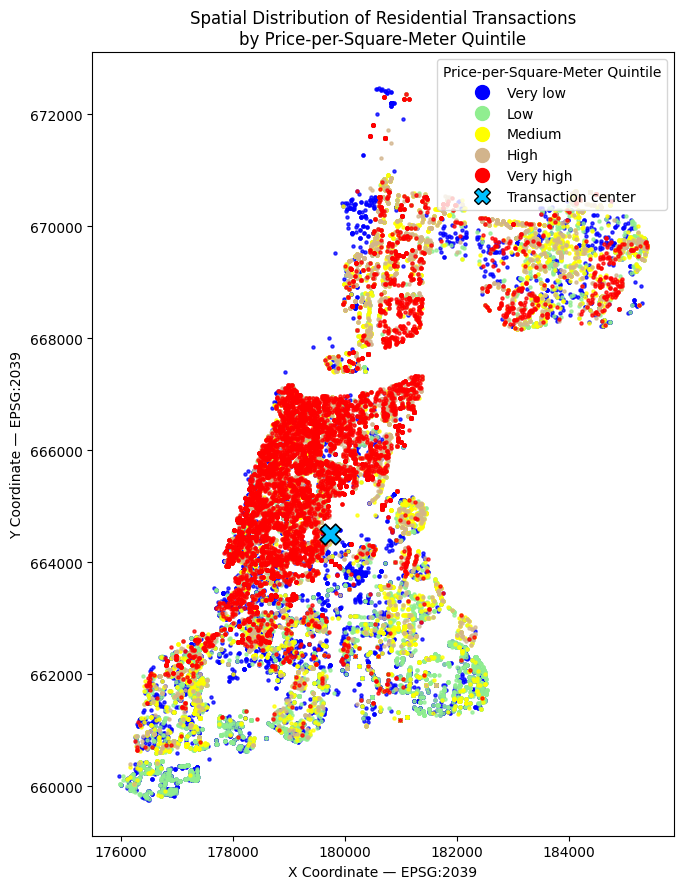

Spatial data preparation was completed successfully.

Coordinate reference system:
EPSG:2039

Spatial bounds:
minimum_x: 175,961.00
minimum_y: 659,754.00
maximum_x: 185,397.38
maximum_y: 672,471.00

Data-derived transaction center in EPSG:2039:
X: 179,735.14, Y: 664,504.35

Data-derived transaction center in EPSG:4326:
Longitude: 34.783753, Latitude: 32.073123

Distance statistics in kilometers:
count    36495.000000
mean         2.910094
std          1.910238
min          0.042955
25%          1.434344
50%          2.285050
75%          4.023405
max          8.013999
Name: distance_to_transaction_center_km, dtype: float64

Price summary by distance band:


,distance_band,transaction_count,mean_distance_km,mean_price_per_sqm,median_price_per_sqm,median_log_price_per_sqm
0,0-1 km,3919,0.640042,32273.368705,32277.777778,10.382134
1,1-2 km,11233,1.470216,32779.393320,32061.068702,10.375398
2,2-4 km,12089,2.839382,26128.272922,22656.250000,10.028191
3,4-6 km,5659,4.949578,24950.062061,23745.918670,10.075166
4,More than 6 km,3595,6.911173,26477.234989,25558.000000,10.148706


Example spatial records:


,transaction_id,x_coordinate,y_coordinate,longitude,latitude,distance_to_transaction_center_km,distance_band,price_per_sqm
0,1,176488.0000,659754.0000,34.749575,32.030167,5.754106,4-6 km,13536.795471
1,2,176512.0000,659755.0000,34.749829,32.030177,5.739769,4-6 km,13511.757828
2,3,176465.8868,659765.2835,34.749341,32.030268,5.757323,4-6 km,6161.731207
3,4,176502.0882,659782.1090,34.749723,32.030421,5.722952,4-6 km,14637.904468
4,5,176502.0882,659782.1090,34.749723,32.030421,5.722952,4-6 km,16989.022478


In [18]:
# ============================================
# Part 5: Spatial preparation and location variables
# ============================================

import subprocess
import sys

try:
    import geopandas as gpd
    from shapely.geometry import Point
except ImportError:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "geopandas"]
    )

    import geopandas as gpd
    from shapely.geometry import Point


# --------------------------------------------
# 1. Define coordinate reference systems
# --------------------------------------------

source_crs = "EPSG:2039"
geographic_crs = "EPSG:4326"


# --------------------------------------------
# 2. Create point geometry from the coordinates
# --------------------------------------------

analysis_geometry = gpd.points_from_xy(
    analysis_df["x_coordinate"],
    analysis_df["y_coordinate"]
)

analysis_gdf = gpd.GeoDataFrame(
    analysis_df.copy(),
    geometry=analysis_geometry,
    crs=source_crs
)


# --------------------------------------------
# 3. Validate the spatial data
# --------------------------------------------

if analysis_gdf.geometry.isna().any():
    raise ValueError(
        "The GeoDataFrame contains missing geometries."
    )

if analysis_gdf.geometry.is_empty.any():
    raise ValueError(
        "The GeoDataFrame contains empty geometries."
    )

if analysis_gdf.crs is None:
    raise ValueError(
        "The coordinate reference system was not assigned."
    )


# --------------------------------------------
# 4. Calculate spatial bounds
# --------------------------------------------

minimum_x, minimum_y, maximum_x, maximum_y = (
    analysis_gdf.total_bounds
)

spatial_bounds = {
    "minimum_x": float(minimum_x),
    "minimum_y": float(minimum_y),
    "maximum_x": float(maximum_x),
    "maximum_y": float(maximum_y)
}


# --------------------------------------------
# 5. Create a data-derived transaction center
# --------------------------------------------

# Median coordinates are less affected by spatially extreme observations.
center_coordinates = (
    float(np.nanmedian(analysis_gdf["x_coordinate"])),
    float(np.nanmedian(analysis_gdf["y_coordinate"]))
)

transaction_center_point = Point(
    center_coordinates
)

transaction_center_gdf = gpd.GeoDataFrame(
    {
        "reference_name": ["Transaction center"],
        "x_coordinate": [center_coordinates[0]],
        "y_coordinate": [center_coordinates[1]]
    },
    geometry=[transaction_center_point],
    crs=source_crs
)


# --------------------------------------------
# 6. Calculate distance from the transaction center
# --------------------------------------------

# EPSG:2039 uses meters, so the result is divided by 1,000
# to convert the distance to kilometers.
analysis_gdf["distance_to_transaction_center_km"] = (
    analysis_gdf.geometry.distance(
        transaction_center_point
    )
    / 1000
)


# --------------------------------------------
# 7. Create distance-based variables
# --------------------------------------------

analysis_gdf["is_within_1km_of_center"] = (
    analysis_gdf[
        "distance_to_transaction_center_km"
    ].le(1)
).astype("int8")

distance_band_limits = [
    -np.inf,
    1,
    2,
    4,
    6,
    np.inf
]

distance_band_labels = [
    "0-1 km",
    "1-2 km",
    "2-4 km",
    "4-6 km",
    "More than 6 km"
]

analysis_gdf["distance_band"] = pd.cut(
    analysis_gdf["distance_to_transaction_center_km"],
    bins=distance_band_limits,
    labels=distance_band_labels,
    include_lowest=True
)


# --------------------------------------------
# 8. Convert a copy to geographic coordinates
# --------------------------------------------

# EPSG:4326 is useful for web maps and geographic longitude-latitude output.
analysis_gdf_wgs84 = analysis_gdf.to_crs(
    geographic_crs
)

transaction_center_wgs84 = (
    transaction_center_gdf.to_crs(
        geographic_crs
    )
)

analysis_gdf["longitude"] = (
    analysis_gdf_wgs84.geometry.x
)

analysis_gdf["latitude"] = (
    analysis_gdf_wgs84.geometry.y
)


# --------------------------------------------
# 9. Create summaries by distance band
# --------------------------------------------

distance_band_summary = (
    analysis_gdf
    .groupby("distance_band", observed=True)
    .agg(
        transaction_count=("transaction_id", "count"),
        mean_distance_km=(
            "distance_to_transaction_center_km",
            "mean"
        ),
        mean_price_per_sqm=("price_per_sqm", "mean"),
        median_price_per_sqm=("price_per_sqm", "median"),
        median_log_price_per_sqm=(
            "log_price_per_sqm",
            "median"
        )
    )
    .reset_index()
)


# --------------------------------------------
# 10. Create price-per-square-meter quintiles
# --------------------------------------------

quintile_labels = [
    "Very low",
    "Low",
    "Medium",
    "High",
    "Very high"
]

analysis_gdf["price_per_sqm_quintile"] = pd.qcut(
    analysis_gdf["price_per_sqm"],
    q=5,
    labels=quintile_labels,
    duplicates="drop"
)


# --------------------------------------------
# 11. Create a transaction location map by quintile
# --------------------------------------------

from matplotlib.lines import Line2D

quintile_order = [
    "Very low",
    "Low",
    "Medium",
    "High",
    "Very high"
]

quintile_color_mapping = {
    "Very low": "blue",
    "Low": "lightgreen",
    "Medium": "yellow",
    "High": "tan",
    "Very high": "red"
}

figure_5, axis_5 = plt.subplots(figsize=(9, 9))

for quintile in quintile_order:
    subset = analysis_gdf[
        analysis_gdf["price_per_sqm_quintile"] == quintile
    ]

    subset.plot(
        ax=axis_5,
        color=quintile_color_mapping[quintile],
        markersize=5,
        alpha=0.75,
        label=quintile
    )

transaction_center_gdf.plot(
    ax=axis_5,
    marker="X",
    color="deepskyblue",
    markersize=220,
    edgecolor="black",
    linewidth=1.2
)

legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label=quintile,
        markerfacecolor=quintile_color_mapping[quintile],
        markeredgecolor=quintile_color_mapping[quintile],
        markersize=10
    )
    for quintile in quintile_order
]

legend_handles.append(
    Line2D(
        [0], [0],
        marker="X",
        color="w",
        label="Transaction center",
        markerfacecolor="deepskyblue",
        markeredgecolor="black",
        markersize=12
    )
)

axis_5.legend(
    handles=legend_handles,
    title="Price-per-Square-Meter Quintile",
    loc="upper right"
)

axis_5.set_title(
    "Spatial Distribution of Residential Transactions\n"
    "by Price-per-Square-Meter Quintile"
)
axis_5.set_xlabel("X Coordinate — EPSG:2039")
axis_5.set_ylabel("Y Coordinate — EPSG:2039")

figure_5.tight_layout()

figure_5.savefig(
    figure_output_folder / "figure_5_transaction_locations.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close(figure_5)


# --------------------------------------------
# 12. Validate the new spatial variables
# --------------------------------------------

if (
    analysis_gdf[
        "distance_to_transaction_center_km"
    ].isna().any()
):
    raise ValueError(
        "Missing values were created in the distance variable."
    )

if (
    analysis_gdf[
        "distance_to_transaction_center_km"
    ].lt(0).any()
):
    raise ValueError(
        "Negative spatial distances were calculated."
    )

if not (
    figure_output_folder
    / "figure_5_transaction_locations.png"
).exists():
    raise FileNotFoundError(
        "The spatial transaction map was not saved."
    )


# --------------------------------------------
# 13. Update the analytical DataFrame
# --------------------------------------------

# Keep a regular DataFrame version with the newly created
# spatial explanatory variables for later machine-learning models.
analysis_df = pd.DataFrame(
    analysis_gdf.drop(columns="geometry")
)


# --------------------------------------------
# 14. Display the spatial results
# --------------------------------------------

print("Spatial data preparation was completed successfully.")
print()

print("Coordinate reference system:")
print(analysis_gdf.crs)
print()

print("Spatial bounds:")
for bound_name, bound_value in spatial_bounds.items():
    print(f"{bound_name}: {bound_value:,.2f}")

print()

print("Data-derived transaction center in EPSG:2039:")
print(
    f"X: {center_coordinates[0]:,.2f}, "
    f"Y: {center_coordinates[1]:,.2f}"
)

print()

center_longitude = (
    transaction_center_wgs84.geometry.x.iloc[0]
)

center_latitude = (
    transaction_center_wgs84.geometry.y.iloc[0]
)

print("Data-derived transaction center in EPSG:4326:")
print(
    f"Longitude: {center_longitude:.6f}, "
    f"Latitude: {center_latitude:.6f}"
)

print()

print("Distance statistics in kilometers:")
print(
    analysis_gdf[
        "distance_to_transaction_center_km"
    ].describe()
)

print()

print("Price summary by distance band:")
display(distance_band_summary)

print("Example spatial records:")
display(
    analysis_gdf[
        [
            "transaction_id",
            "x_coordinate",
            "y_coordinate",
            "longitude",
            "latitude",
            "distance_to_transaction_center_km",
            "distance_band",
            "price_per_sqm"
        ]
    ].head()
)

# Part 6: Spatial Autocorrelation Analysis with PySAL

This section examines whether residential prices exhibit statistically significant spatial clustering.

Individual transactions are aggregated into 500-by-500-meter grid cells. For each occupied cell, the median log price per square meter and the number of transactions are calculated.

Aggregation is used for three reasons:

- Multiple transactions may occur at the same or nearly identical location.
- An analysis of more than 36,000 individual points would be computationally intensive.
- Grid-cell medians reduce the influence of extreme individual transactions and represent local price conditions more clearly.

Spatial relationships between occupied grid cells are defined using the eight nearest neighboring cells. Row-standardized spatial weights are then used to calculate:

- Global Moran's I, which tests whether similar values are spatially clustered across the study area.
- Local Moran's I (LISA), which identifies significant local clusters and spatial outliers.

The LISA categories are:

- `High-High`: a high-value cell surrounded by high-value neighboring cells.
- `Low-Low`: a low-value cell surrounded by low-value neighboring cells.
- `High-Low`: a high-value cell surrounded by low-value neighboring cells.
- `Low-High`: a low-value cell surrounded by high-value neighboring cells.
- `Not significant`: no statistically significant local pattern at the 5% level.

The results describe spatial association and should not be interpreted as evidence that location alone causes property prices.

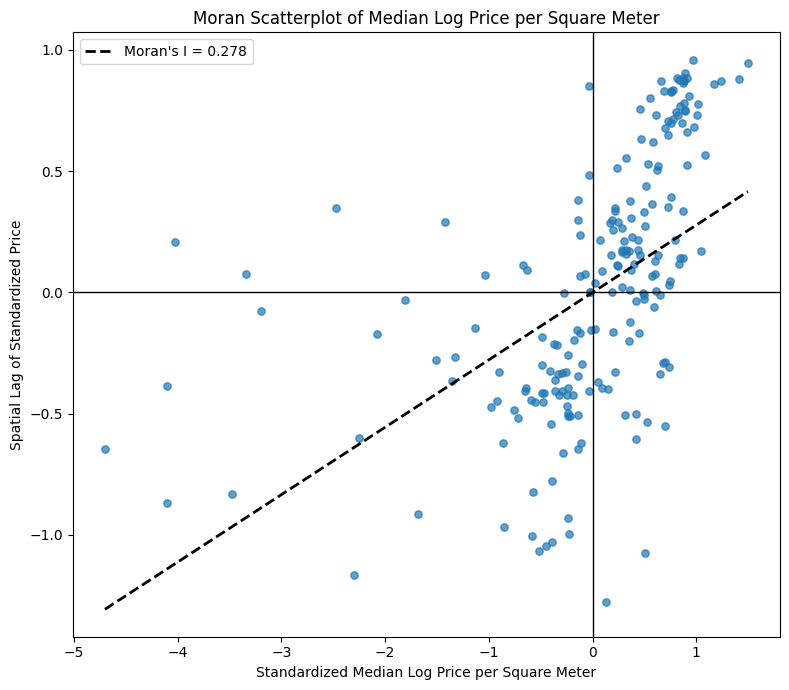

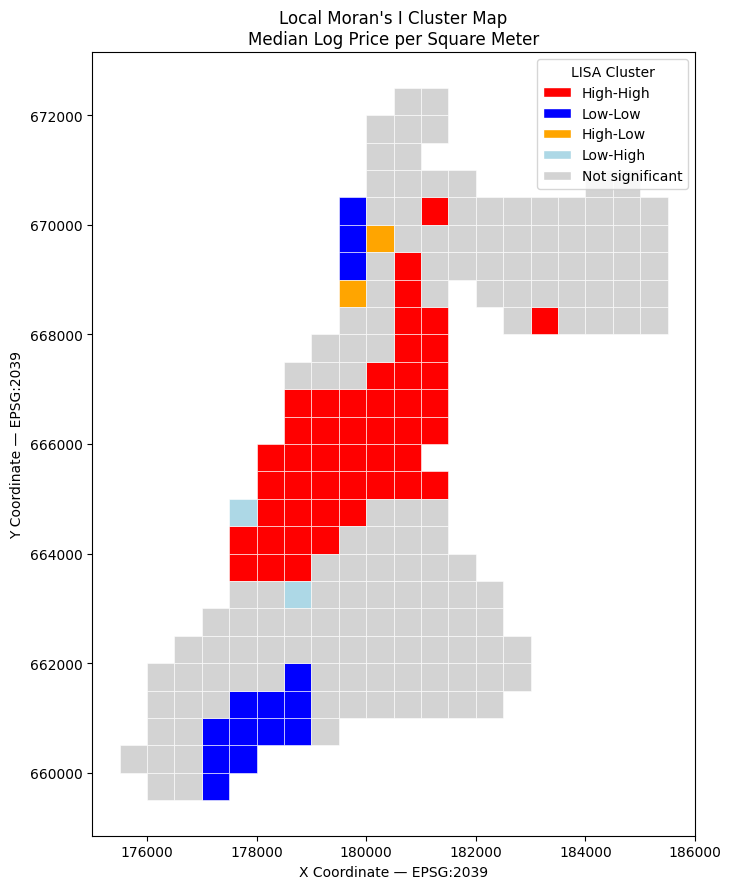

PySAL spatial analysis was completed successfully.

Grid information:
Grid-cell size: 500 x 500 meters
Occupied grid cells: 207
Nearest neighbors per cell: 8

Global Moran's I results:
morans_i: 0.277969
expected_i: -0.004854
permutation_p_value: 0.001000
permutation_z_score: 8.480116

Interpretation: statistically significant positive spatial autocorrelation was detected.

LISA cluster summary:


,lisa_cluster,grid_cell_count,percentage_of_cells
0,High-High,47,22.705314
1,Low-Low,14,6.763285
2,High-Low,2,0.966184
3,Low-High,2,0.966184
4,Not significant,142,68.599034


Examples of significant local clusters:


,grid_cell_id,transaction_count,median_price_per_sqm,median_log_price_per_sqm,local_morans_i,local_moran_p_value,lisa_cluster
36,178000_664000,641,35357.142857,10.473256,0.552702,0.001,High-High
37,178000_664500,566,37696.078431,10.537311,0.680996,0.001,High-High
38,178000_665000,316,40878.154971,10.618344,0.733416,0.001,High-High
39,178000_665500,76,45549.655568,10.726558,1.005633,0.001,High-High
47,178500_664000,650,37929.299938,10.543479,0.664339,0.001,High-High
48,178500_664500,564,33391.367422,10.416049,0.568292,0.001,High-High
49,178500_665000,427,32930.280422,10.402148,0.576095,0.001,High-High
50,178500_665500,475,38611.111111,10.561295,0.804606,0.001,High-High
51,178500_666000,488,37635.008259,10.535686,0.768503,0.001,High-High
52,178500_666500,172,37816.642455,10.540470,0.767755,0.001,High-High


In [19]:
# ============================================
# Part 6: Spatial autocorrelation with PySAL
# ============================================

import subprocess
import sys

try:
    from libpysal.weights import KNN
    from libpysal.weights.spatial_lag import lag_spatial
    from esda.moran import Moran, Moran_Local
    from shapely.geometry import box
except ImportError:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "libpysal",
            "esda"
        ]
    )

    from libpysal.weights import KNN
    from libpysal.weights.spatial_lag import lag_spatial
    from esda.moran import Moran, Moran_Local
    from shapely.geometry import box


# --------------------------------------------
# 1. Define the spatial grid size
# --------------------------------------------

grid_cell_size_meters = 500


# --------------------------------------------
# 2. Assign each transaction to a grid cell
# --------------------------------------------

analysis_gdf["grid_x_min"] = (
    np.floor(
        analysis_gdf["x_coordinate"]
        / grid_cell_size_meters
    )
    * grid_cell_size_meters
)

analysis_gdf["grid_y_min"] = (
    np.floor(
        analysis_gdf["y_coordinate"]
        / grid_cell_size_meters
    )
    * grid_cell_size_meters
)

analysis_gdf["grid_cell_id"] = (
    analysis_gdf["grid_x_min"].astype(int).astype(str)
    + "_"
    + analysis_gdf["grid_y_min"].astype(int).astype(str)
)


# --------------------------------------------
# 3. Aggregate transactions within each grid cell
# --------------------------------------------

grid_summary = (
    analysis_gdf
    .groupby(
        [
            "grid_cell_id",
            "grid_x_min",
            "grid_y_min"
        ],
        as_index=False
    )
    .agg(
        transaction_count=("transaction_id", "count"),
        median_price_per_sqm=("price_per_sqm", "median"),
        mean_price_per_sqm=("price_per_sqm", "mean"),
        median_log_price_per_sqm=(
            "log_price_per_sqm",
            "median"
        )
    )
)


# --------------------------------------------
# 4. Create polygon geometry for occupied cells
# --------------------------------------------

grid_geometry = [
    box(
        x_min,
        y_min,
        x_min + grid_cell_size_meters,
        y_min + grid_cell_size_meters
    )
    for x_min, y_min in zip(
        grid_summary["grid_x_min"],
        grid_summary["grid_y_min"]
    )
]

price_grid_gdf = gpd.GeoDataFrame(
    grid_summary,
    geometry=grid_geometry,
    crs=source_crs
)


# --------------------------------------------
# 5. Validate the number of occupied cells
# --------------------------------------------

if len(price_grid_gdf) < 10:
    raise ValueError(
        "Too few occupied grid cells were created for spatial analysis."
    )


# --------------------------------------------
# 6. Create spatial weights using nearest neighbors
# --------------------------------------------

# Eight nearest neighbors are used so that every occupied grid cell
# has a defined spatial relationship, including cells near the boundary.
number_of_neighbors = min(
    8,
    len(price_grid_gdf) - 1
)

spatial_weights = KNN.from_dataframe(
    price_grid_gdf,
    k=number_of_neighbors
)

# Row standardization makes the neighboring weights of each cell sum to one.
spatial_weights.transform = "R"


# --------------------------------------------
# 7. Prepare the spatial analysis variable
# --------------------------------------------

spatial_price_values = price_grid_gdf[
    "median_log_price_per_sqm"
].to_numpy(dtype=float)

spatial_price_mean = np.mean(spatial_price_values)
spatial_price_standard_deviation = np.std(
    spatial_price_values
)

if spatial_price_standard_deviation == 0:
    raise ValueError(
        "The spatial price variable has no variation."
    )

standardized_spatial_price = (
    spatial_price_values - spatial_price_mean
) / spatial_price_standard_deviation


# --------------------------------------------
# 8. Calculate Global Moran's I
# --------------------------------------------

global_moran = Moran(
    standardized_spatial_price,
    spatial_weights,
    permutations=999
)

global_moran_results = {
    "morans_i": float(global_moran.I),
    "expected_i": float(global_moran.EI),
    "permutation_p_value": float(global_moran.p_sim),
    "permutation_z_score": float(global_moran.z_sim)
}


# --------------------------------------------
# 9. Calculate Local Moran's I
# --------------------------------------------

local_moran = Moran_Local(
    standardized_spatial_price,
    spatial_weights,
    permutations=999,
    seed=42
)

price_grid_gdf["local_morans_i"] = (
    local_moran.Is
)

price_grid_gdf["local_moran_p_value"] = (
    local_moran.p_sim
)

price_grid_gdf["lisa_quadrant"] = (
    local_moran.q
)

price_grid_gdf["is_lisa_significant"] = (
    price_grid_gdf["local_moran_p_value"] < 0.05
).astype("int8")


# --------------------------------------------
# 10. Classify significant LISA results
# --------------------------------------------

lisa_category_mapping = {
    1: "High-High",
    2: "Low-High",
    3: "Low-Low",
    4: "High-Low"
}

price_grid_gdf["lisa_cluster"] = [
    (
        lisa_category_mapping[quadrant]
        if is_significant == 1
        else "Not significant"
    )
    for quadrant, is_significant in zip(
        price_grid_gdf["lisa_quadrant"],
        price_grid_gdf["is_lisa_significant"]
    )
]

lisa_category_order = [
    "High-High",
    "Low-Low",
    "High-Low",
    "Low-High",
    "Not significant"
]

price_grid_gdf["lisa_cluster"] = pd.Categorical(
    price_grid_gdf["lisa_cluster"],
    categories=lisa_category_order,
    ordered=True
)


# --------------------------------------------
# 11. Create the Moran scatterplot
# --------------------------------------------

spatial_lag_values = lag_spatial(
    spatial_weights,
    standardized_spatial_price
)

figure_6, axis_6 = plt.subplots(figsize=(8, 7))

axis_6.scatter(
    standardized_spatial_price,
    spatial_lag_values,
    alpha=0.7,
    s=28
)

axis_6.axhline(
    0,
    color="black",
    linewidth=1
)

axis_6.axvline(
    0,
    color="black",
    linewidth=1
)

scatter_x_limits = np.array(
    [
        standardized_spatial_price.min(),
        standardized_spatial_price.max()
    ]
)

axis_6.plot(
    scatter_x_limits,
    global_moran.I * scatter_x_limits,
    linestyle="--",
    color="black",
    linewidth=2,
    label=f"Moran's I = {global_moran.I:.3f}"
)

axis_6.set_title(
    "Moran Scatterplot of Median Log Price per Square Meter"
)
axis_6.set_xlabel(
    "Standardized Median Log Price per Square Meter"
)
axis_6.set_ylabel(
    "Spatial Lag of Standardized Price"
)
axis_6.legend()

figure_6.tight_layout()

figure_6.savefig(
    figure_output_folder / "figure_6_moran_scatterplot.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close(figure_6)


# --------------------------------------------
# 12. Create the LISA cluster map
# --------------------------------------------

lisa_color_mapping = {
    "High-High": "red",
    "Low-Low": "blue",
    "High-Low": "orange",
    "Low-High": "lightblue",
    "Not significant": "lightgrey"
}

figure_7, axis_7 = plt.subplots(figsize=(9, 9))

for lisa_category in lisa_category_order:
    category_cells = price_grid_gdf.loc[
        price_grid_gdf["lisa_cluster"] == lisa_category
    ]

    if not category_cells.empty:
        category_cells.plot(
            ax=axis_7,
            color=lisa_color_mapping[lisa_category],
            edgecolor="white",
            linewidth=0.4,
            label=lisa_category
        )

axis_7.set_title(
    "Local Moran's I Cluster Map\n"
    "Median Log Price per Square Meter"
)
axis_7.set_xlabel("X Coordinate — EPSG:2039")
axis_7.set_ylabel("Y Coordinate — EPSG:2039")

from matplotlib.patches import Patch

lisa_legend_handles = [
    Patch(
        facecolor=lisa_color_mapping[lisa_category],
        edgecolor="white",
        label=lisa_category
    )
    for lisa_category in lisa_category_order
]

axis_7.legend(
    handles=lisa_legend_handles,
    title="LISA Cluster",
    loc="upper right"
)

figure_7.tight_layout()

figure_7.savefig(
    figure_output_folder / "figure_7_lisa_cluster_map.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close(figure_7)


# --------------------------------------------
# 13. Create LISA summary tables
# --------------------------------------------

lisa_cluster_summary = (
    price_grid_gdf["lisa_cluster"]
    .value_counts(dropna=False)
    .reindex(lisa_category_order, fill_value=0)
    .rename_axis("lisa_cluster")
    .reset_index(name="grid_cell_count")
)

lisa_cluster_summary["percentage_of_cells"] = (
    lisa_cluster_summary["grid_cell_count"]
    / len(price_grid_gdf)
    * 100
)

significant_lisa_cells = (
    price_grid_gdf.loc[
        price_grid_gdf["is_lisa_significant"].eq(1),
        [
            "grid_cell_id",
            "transaction_count",
            "median_price_per_sqm",
            "median_log_price_per_sqm",
            "local_morans_i",
            "local_moran_p_value",
            "lisa_cluster",
            "geometry"
        ]
    ]
    .sort_values(
        [
            "lisa_cluster",
            "local_moran_p_value"
        ]
    )
)


# --------------------------------------------
# 14. Validate the PySAL results
# --------------------------------------------

if not np.isfinite(global_moran.I):
    raise ValueError(
        "Global Moran's I was not calculated successfully."
    )

if price_grid_gdf["local_morans_i"].isna().any():
    raise ValueError(
        "Missing Local Moran's I values were created."
    )

expected_spatial_figures = [
    "figure_6_moran_scatterplot.png",
    "figure_7_lisa_cluster_map.png"
]

missing_spatial_figures = [
    file_name
    for file_name in expected_spatial_figures
    if not (
        figure_output_folder / file_name
    ).exists()
]

if missing_spatial_figures:
    raise FileNotFoundError(
        "The following spatial figures were not saved: "
        f"{missing_spatial_figures}"
    )


# --------------------------------------------
# 15. Display the spatial analysis results
# --------------------------------------------

print("PySAL spatial analysis was completed successfully.")
print()

print("Grid information:")
print(
    f"Grid-cell size: "
    f"{grid_cell_size_meters} x "
    f"{grid_cell_size_meters} meters"
)
print(
    f"Occupied grid cells: {len(price_grid_gdf):,}"
)
print(
    f"Nearest neighbors per cell: "
    f"{number_of_neighbors}"
)
print()

print("Global Moran's I results:")
for result_name, result_value in global_moran_results.items():
    print(f"{result_name}: {result_value:.6f}")

print()

if global_moran.p_sim < 0.05:
    if global_moran.I > global_moran.EI:
        print(
            "Interpretation: statistically significant "
            "positive spatial autocorrelation was detected."
        )
    else:
        print(
            "Interpretation: statistically significant "
            "negative spatial autocorrelation was detected."
        )
else:
    print(
        "Interpretation: no statistically significant "
        "global spatial autocorrelation was detected."
    )

print()

print("LISA cluster summary:")
display(lisa_cluster_summary)

print("Examples of significant local clusters:")
display(
    significant_lisa_cells.drop(
        columns="geometry"
    ).head(10)
)

# Part 7: Linear Regression and Model Evaluation

This section applies a multiple linear regression model to examine how selected property and location characteristics are associated with the logarithm of price per square meter.

The model uses a reduced set of explanatory variables to limit overlap between variables describing the same property or spatial characteristic.

The data are divided into training and test samples by complete 500-by-500-meter grid cells. Transactions from the same grid cell cannot appear in both samples.

Missing numerical values are replaced with the median of the training sample, and the explanatory variables are standardized.

The model is evaluated using R-squared, mean absolute error, root mean squared error, and residual diagnostics. The coefficients represent statistical associations rather than causal effects.

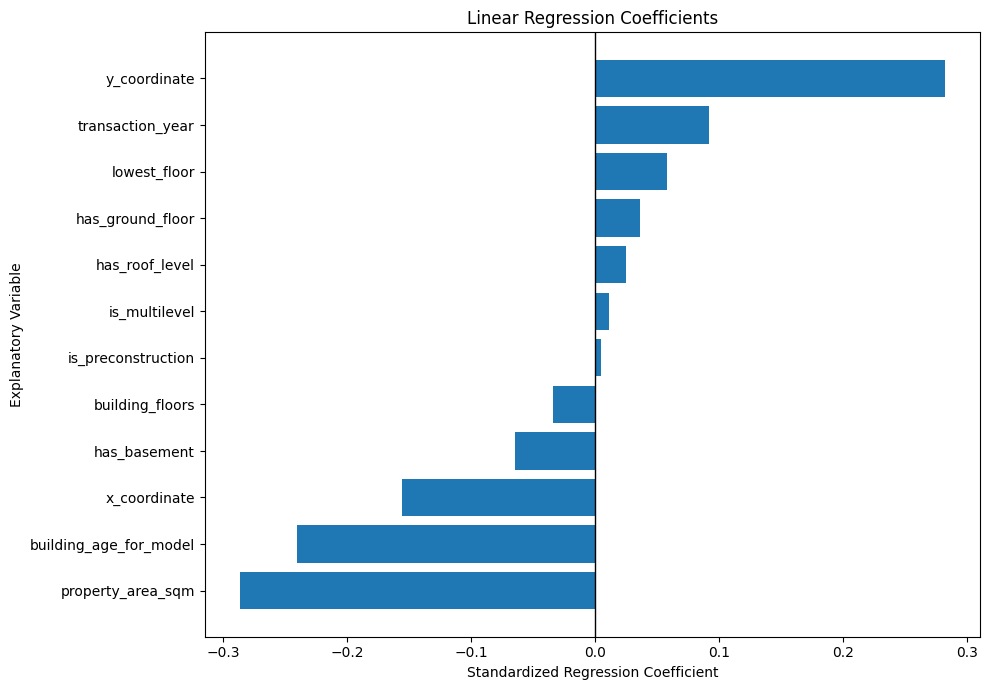

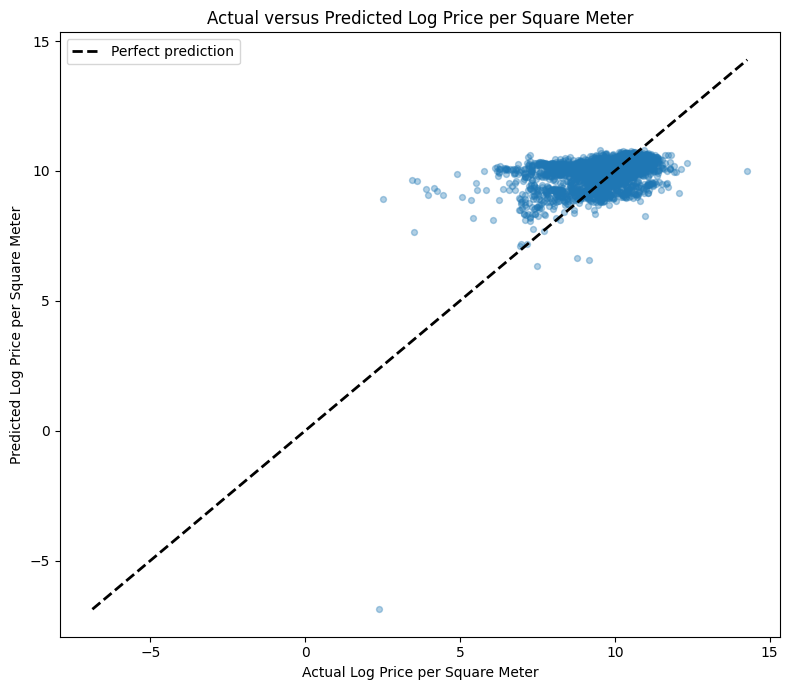

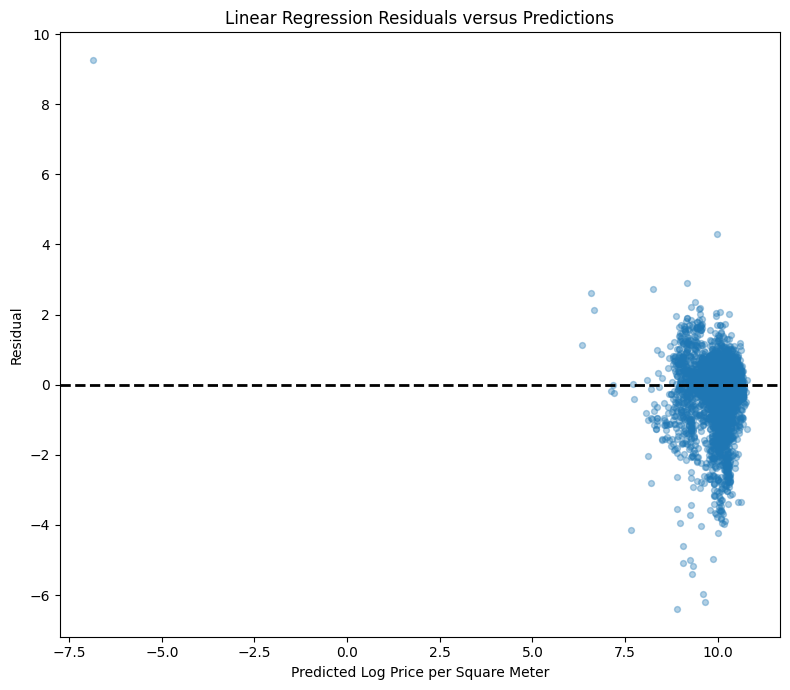

The reduced linear-regression model was completed successfully.

Explanatory variables:
- property_area_sqm
- transaction_year
- building_age_for_model
- building_floors
- lowest_floor
- is_preconstruction
- is_multilevel
- has_basement
- has_ground_floor
- has_roof_level
- x_coordinate
- y_coordinate

Spatial train-test split:
Training records: 29,057
Test records: 7,438
Training grid cells: 165
Test grid cells: 42

Model performance:
train_r_squared_log: 0.2884
test_r_squared_log: 0.2268
test_mae_log: 0.4373
test_rmse_log: 0.7177
test_mae_price_per_sqm: 9,427.0483
test_rmse_price_per_sqm: 22,913.6210

Regression coefficients:


,feature,coefficient,absolute_coefficient
0,property_area_sqm,-0.286517,0.286517
1,y_coordinate,0.281926,0.281926
2,building_age_for_model,-0.240406,0.240406
3,x_coordinate,-0.155887,0.155887
4,transaction_year,0.091507,0.091507
5,has_basement,-0.064227,0.064227
6,lowest_floor,0.058226,0.058226
7,has_ground_floor,0.036504,0.036504
8,building_floors,-0.033719,0.033719
9,has_roof_level,0.024755,0.024755


Example test-set predictions:


,transaction_id,grid_cell_id,price_per_sqm,predicted_price_per_sqm,absolute_error_price_per_sqm
1797,1805,176500_661000,31304.347826,21398.055873,9906.291953
1798,1806,176500_661000,31304.347826,21398.055873,9906.291953
1799,1807,177000_661000,13911.620295,26799.953929,12888.333635
1814,1822,176500_661000,21666.666667,20762.312485,904.354182
1815,1823,176500_661000,19069.767442,21966.914931,2897.147490
1816,1824,176500_661000,5829.614604,8652.859140,2823.244536
1817,1825,178000_661000,13821.138211,16856.124696,3034.986485
1818,1826,178000_661000,14453.781513,18510.383071,4056.601558
1819,1827,178000_661000,14453.781513,20875.880339,6422.098827
1820,1828,178000_661000,6806.722689,21055.347927,14248.625238


In [20]:
# ============================================
# Part 7: Linear regression and model evaluation
# ============================================

import subprocess
import sys

try:
    from sklearn.impute import SimpleImputer
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import (
        mean_absolute_error,
        mean_squared_error,
        r2_score
    )
    from sklearn.model_selection import GroupShuffleSplit
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler
except ImportError:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "scikit-learn"
        ]
    )

    from sklearn.impute import SimpleImputer
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import (
        mean_absolute_error,
        mean_squared_error,
        r2_score
    )
    from sklearn.model_selection import GroupShuffleSplit
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler


# --------------------------------------------
# 1. Define the target and explanatory variables
# --------------------------------------------

target_variable = "log_price_per_sqm"

model_features = [
    "property_area_sqm",
    "transaction_year",
    "building_age_for_model",
    "building_floors",
    "lowest_floor",
    "is_preconstruction",
    "is_multilevel",
    "has_basement",
    "has_ground_floor",
    "has_roof_level",
    "x_coordinate",
    "y_coordinate"
]


# --------------------------------------------
# 2. Prepare the modeling dataset
# --------------------------------------------

model_df = analysis_gdf[
    model_features
    + [
        target_variable,
        "price_per_sqm",
        "grid_cell_id",
        "transaction_id"
    ]
].copy()

model_df = model_df.loc[
    model_df[target_variable].notna()
    & model_df["grid_cell_id"].notna()
].reset_index(drop=True)

X = model_df[model_features]
y = model_df[target_variable]

spatial_groups = model_df["grid_cell_id"]


# --------------------------------------------
# 3. Create a spatial train-test split
# --------------------------------------------

spatial_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_indices, test_indices = next(
    spatial_splitter.split(
        X,
        y,
        groups=spatial_groups
    )
)

X_train = X.iloc[train_indices].copy()
X_test = X.iloc[test_indices].copy()

y_train = y.iloc[train_indices].copy()
y_test = y.iloc[test_indices].copy()

test_metadata = model_df.iloc[test_indices][
    [
        "transaction_id",
        "grid_cell_id",
        "price_per_sqm"
    ]
].copy()


# --------------------------------------------
# 4. Validate the spatial split
# --------------------------------------------

training_grid_cells = set(
    spatial_groups.iloc[train_indices]
)

test_grid_cells = set(
    spatial_groups.iloc[test_indices]
)

overlapping_grid_cells = (
    training_grid_cells
    .intersection(test_grid_cells)
)

if overlapping_grid_cells:
    raise ValueError(
        "At least one grid cell appears in both "
        "the training and test samples."
    )


# --------------------------------------------
# 5. Define the regression pipeline
# --------------------------------------------

model_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "standard_scaler",
            StandardScaler()
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)


# --------------------------------------------
# 6. Train the model
# --------------------------------------------

model_pipeline.fit(
    X_train,
    y_train
)


# --------------------------------------------
# 7. Generate predictions
# --------------------------------------------

train_predictions_log = model_pipeline.predict(
    X_train
)

test_predictions_log = model_pipeline.predict(
    X_test
)

test_predictions_price = np.exp(
    test_predictions_log
)

test_actual_price = np.exp(
    y_test.to_numpy(dtype=float)
)


# --------------------------------------------
# 8. Calculate residuals
# --------------------------------------------

test_residuals_log = (
    y_test.to_numpy(dtype=float)
    - test_predictions_log
)


# --------------------------------------------
# 9. Calculate model-performance measures
# --------------------------------------------

model_performance = {
    "training_records": len(X_train),
    "test_records": len(X_test),
    "training_grid_cells": len(training_grid_cells),
    "test_grid_cells": len(test_grid_cells),
    "train_r_squared_log": r2_score(
        y_train,
        train_predictions_log
    ),
    "test_r_squared_log": r2_score(
        y_test,
        test_predictions_log
    ),
    "test_mae_log": mean_absolute_error(
        y_test,
        test_predictions_log
    ),
    "test_rmse_log": np.sqrt(
        mean_squared_error(
            y_test,
            test_predictions_log
        )
    ),
    "test_mae_price_per_sqm": mean_absolute_error(
        test_actual_price,
        test_predictions_price
    ),
    "test_rmse_price_per_sqm": np.sqrt(
        mean_squared_error(
            test_actual_price,
            test_predictions_price
        )
    )
}


# --------------------------------------------
# 10. Create a prediction-results table
# --------------------------------------------

prediction_results = test_metadata.copy()

prediction_results["actual_log_price_per_sqm"] = (
    y_test.to_numpy(dtype=float)
)

prediction_results["predicted_log_price_per_sqm"] = (
    test_predictions_log
)

prediction_results["predicted_price_per_sqm"] = (
    test_predictions_price
)

prediction_results["residual_log_price_per_sqm"] = (
    test_residuals_log
)

prediction_results["absolute_error_price_per_sqm"] = (
    np.abs(
        prediction_results["price_per_sqm"]
        - prediction_results["predicted_price_per_sqm"]
    )
)


# --------------------------------------------
# 11. Extract regression coefficients
# --------------------------------------------

regression_coefficients = (
    model_pipeline
    .named_steps["model"]
    .coef_
)

coefficient_df = pd.DataFrame(
    {
        "feature": model_features,
        "coefficient": regression_coefficients
    }
)

coefficient_df["absolute_coefficient"] = (
    coefficient_df["coefficient"].abs()
)

coefficient_df = (
    coefficient_df
    .sort_values(
        "absolute_coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)


# --------------------------------------------
# 12. Create the coefficient figure
# --------------------------------------------

coefficient_plot_df = (
    coefficient_df
    .sort_values(
        "coefficient",
        ascending=True
    )
)

figure_8, axis_8 = plt.subplots(
    figsize=(10, 7)
)

axis_8.barh(
    coefficient_plot_df["feature"],
    coefficient_plot_df["coefficient"]
)

axis_8.axvline(
    0,
    color="black",
    linewidth=1
)

axis_8.set_title(
    "Linear Regression Coefficients"
)
axis_8.set_xlabel(
    "Standardized Regression Coefficient"
)
axis_8.set_ylabel(
    "Explanatory Variable"
)

figure_8.tight_layout()

figure_8.savefig(
    figure_output_folder
    / "figure_8_linear_regression_coefficients.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close(figure_8)


# --------------------------------------------
# 13. Create actual-versus-predicted figure
# --------------------------------------------

figure_9, axis_9 = plt.subplots(
    figsize=(8, 7)
)

axis_9.scatter(
    y_test,
    test_predictions_log,
    alpha=0.35,
    s=18
)

comparison_minimum = min(
    y_test.min(),
    test_predictions_log.min()
)

comparison_maximum = max(
    y_test.max(),
    test_predictions_log.max()
)

axis_9.plot(
    [
        comparison_minimum,
        comparison_maximum
    ],
    [
        comparison_minimum,
        comparison_maximum
    ],
    linestyle="--",
    color="black",
    linewidth=2,
    label="Perfect prediction"
)

axis_9.set_title(
    "Actual versus Predicted Log Price per Square Meter"
)
axis_9.set_xlabel(
    "Actual Log Price per Square Meter"
)
axis_9.set_ylabel(
    "Predicted Log Price per Square Meter"
)
axis_9.legend()

figure_9.tight_layout()

figure_9.savefig(
    figure_output_folder
    / "figure_9_actual_vs_predicted_linear_regression.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close(figure_9)


# --------------------------------------------
# 14. Create residual-diagnostics figure
# --------------------------------------------

figure_10, axis_10 = plt.subplots(
    figsize=(8, 7)
)

axis_10.scatter(
    test_predictions_log,
    test_residuals_log,
    alpha=0.35,
    s=18
)

axis_10.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=2
)

axis_10.set_title(
    "Linear Regression Residuals versus Predictions"
)
axis_10.set_xlabel(
    "Predicted Log Price per Square Meter"
)
axis_10.set_ylabel(
    "Residual"
)

figure_10.tight_layout()

figure_10.savefig(
    figure_output_folder
    / "figure_10_linear_regression_residuals.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close(figure_10)


# --------------------------------------------
# 15. Validate the model outputs
# --------------------------------------------

if not np.isfinite(
    test_predictions_log
).all():
    raise ValueError(
        "The model created non-finite predictions."
    )

if not np.isfinite(
    test_residuals_log
).all():
    raise ValueError(
        "The model created non-finite residuals."
    )

expected_model_figures = [
    "figure_8_linear_regression_coefficients.png",
    "figure_9_actual_vs_predicted_linear_regression.png",
    "figure_10_linear_regression_residuals.png"
]

missing_model_figures = [
    file_name
    for file_name in expected_model_figures
    if not (
        figure_output_folder / file_name
    ).exists()
]

if missing_model_figures:
    raise FileNotFoundError(
        "The following model figures were not saved: "
        f"{missing_model_figures}"
    )


# --------------------------------------------
# 16. Display the model results
# --------------------------------------------

print(
    "The reduced linear-regression model "
    "was completed successfully."
)
print()

print("Explanatory variables:")
for feature in model_features:
    print(f"- {feature}")

print()

print("Spatial train-test split:")
print(
    f"Training records: "
    f"{model_performance['training_records']:,}"
)
print(
    f"Test records: "
    f"{model_performance['test_records']:,}"
)
print(
    f"Training grid cells: "
    f"{model_performance['training_grid_cells']:,}"
)
print(
    f"Test grid cells: "
    f"{model_performance['test_grid_cells']:,}"
)
print()

print("Model performance:")

for metric_name, metric_value in model_performance.items():
    if metric_name not in [
        "training_records",
        "test_records",
        "training_grid_cells",
        "test_grid_cells"
    ]:
        print(
            f"{metric_name}: "
            f"{metric_value:,.4f}"
        )

print()

print("Regression coefficients:")
display(coefficient_df)

print("Example test-set predictions:")
display(
    prediction_results[
        [
            "transaction_id",
            "grid_cell_id",
            "price_per_sqm",
            "predicted_price_per_sqm",
            "absolute_error_price_per_sqm"
        ]
    ].head(10)
)

# Part 8: Sensitivity Analysis for Extreme Values

This section tests whether extreme price-per-square-meter observations materially affect the linear-regression results.

The same explanatory variables, preprocessing steps, and spatial training and test grid cells used in the main model are retained. The sensitivity model excludes transactions below the 1st percentile or above the 99th percentile of price per square meter.

The two models are compared according to their predictive performance and standardized regression coefficients. The filtered sample is used only for sensitivity analysis and does not replace the main analytical sample.

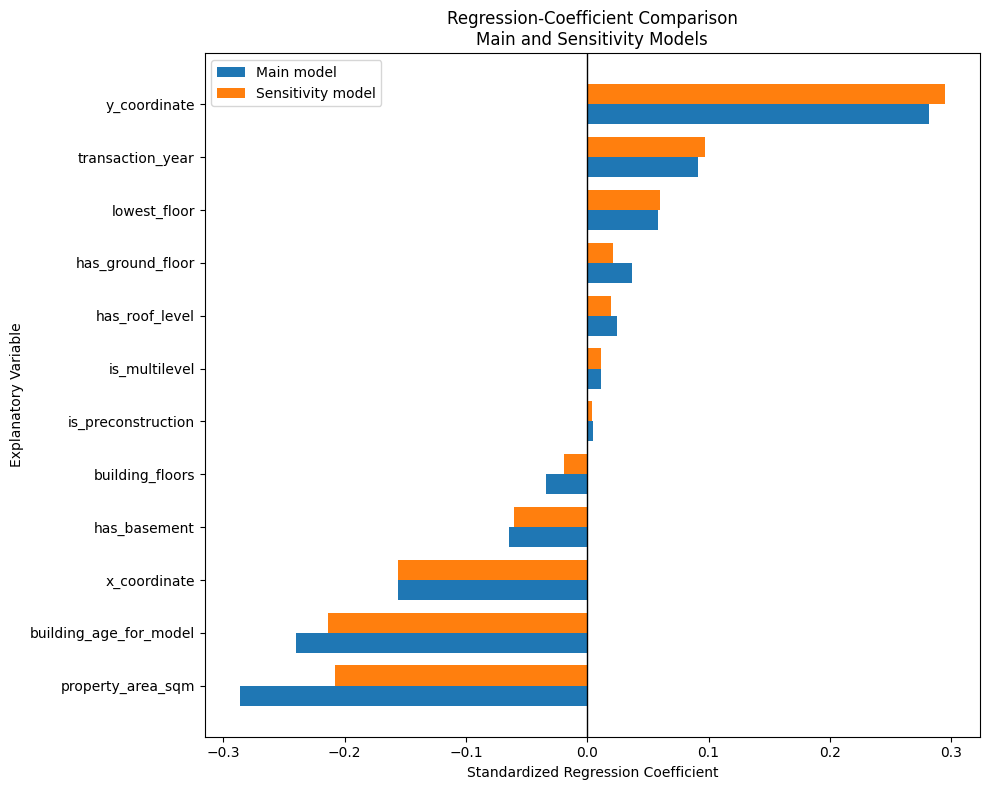

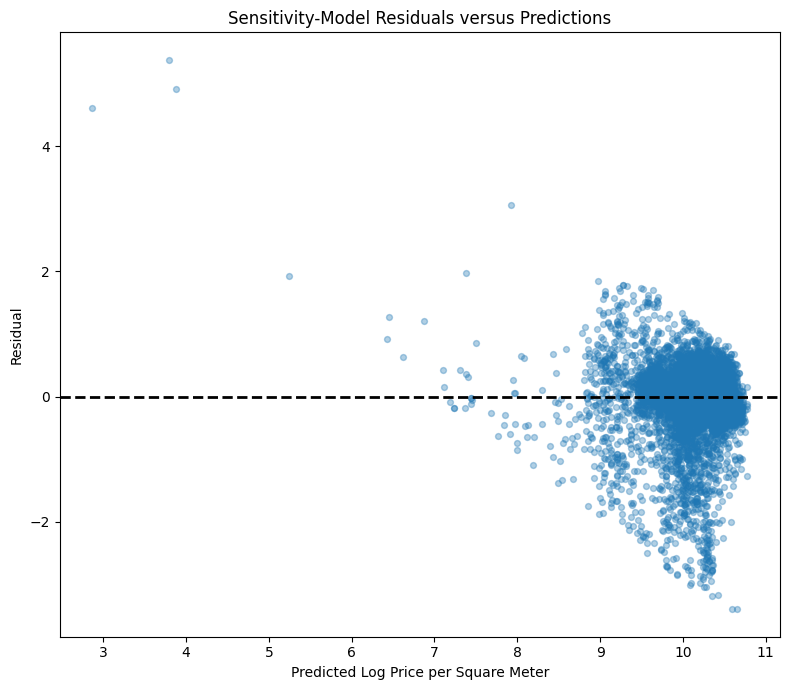

The sensitivity analysis was completed successfully.

Extreme observations excluded from the sensitivity model:
730 records

Model-performance comparison:


,metric,main_model,sensitivity_model,absolute_change,percentage_change
0,Training records,29057.000000,28440.000000,-617.000000,-2.123413
1,Test records,7438.000000,7325.000000,-113.000000,-1.519226
2,Train R-squared,0.288440,0.335407,0.046967,16.283036
3,Test R-squared,0.226750,0.266347,0.039597,17.462741
4,Test MAE log,0.437301,0.391508,-0.045793,-10.471715
5,Test RMSE log,0.717688,0.605800,-0.111888,-15.590032
6,Test MAE price per sqm,9427.048325,8543.235420,-883.812905,-9.375288
7,Test RMSE price per sqm,22913.620952,11847.464858,-11066.156094,-48.295100


Coefficient comparison:


,feature,main_model_coefficient,sensitivity_coefficient,coefficient_change,same_direction
0,property_area_sqm,-0.286517,-0.207970,0.078546,True
1,building_age_for_model,-0.240406,-0.214006,0.026400,True
2,x_coordinate,-0.155887,-0.156332,-0.000445,True
3,has_basement,-0.064227,-0.060649,0.003578,True
4,building_floors,-0.033719,-0.019536,0.014183,True
5,is_preconstruction,0.004422,0.004083,-0.000339,True
6,is_multilevel,0.011090,0.011628,0.000538,True
7,has_roof_level,0.024755,0.019264,-0.005491,True
8,has_ground_floor,0.036504,0.021319,-0.015184,True
9,lowest_floor,0.058226,0.060074,0.001848,True


Coefficients retaining the same direction:
12 out of 12


In [21]:
# ============================================
# Part 8: Sensitivity analysis for extreme values
# ============================================

from sklearn.base import clone


# --------------------------------------------
# 1. Create the sensitivity modeling sample
# --------------------------------------------

# Transactions outside the 1st and 99th percentiles were already
# identified in Part 3. They are excluded only from this sensitivity model.
sensitivity_model_df = analysis_gdf.loc[
    analysis_gdf["is_price_per_sqm_extreme"].eq(0),
    model_features
    + [
        target_variable,
        "price_per_sqm",
        "grid_cell_id",
        "transaction_id"
    ]
].copy()

sensitivity_model_df = sensitivity_model_df.loc[
    sensitivity_model_df[target_variable].notna()
    & sensitivity_model_df["grid_cell_id"].notna()
].reset_index(drop=True)


# --------------------------------------------
# 2. Reuse the original spatial split
# --------------------------------------------

# The same grid cells from the main model are retained so that changes
# in performance reflect the removal of extreme observations rather
# than a different training-test split.
sensitivity_train_condition = (
    sensitivity_model_df["grid_cell_id"].isin(
        training_grid_cells
    )
)

sensitivity_test_condition = (
    sensitivity_model_df["grid_cell_id"].isin(
        test_grid_cells
    )
)

sensitivity_train_df = sensitivity_model_df.loc[
    sensitivity_train_condition
].copy()

sensitivity_test_df = sensitivity_model_df.loc[
    sensitivity_test_condition
].copy()

X_train_sensitivity = sensitivity_train_df[
    model_features
].copy()

X_test_sensitivity = sensitivity_test_df[
    model_features
].copy()

y_train_sensitivity = sensitivity_train_df[
    target_variable
].copy()

y_test_sensitivity = sensitivity_test_df[
    target_variable
].copy()


# --------------------------------------------
# 3. Validate the sensitivity samples
# --------------------------------------------

if X_train_sensitivity.empty:
    raise ValueError(
        "The sensitivity training sample is empty."
    )

if X_test_sensitivity.empty:
    raise ValueError(
        "The sensitivity test sample is empty."
    )

sensitivity_overlap = set(
    sensitivity_train_df["grid_cell_id"]
).intersection(
    set(sensitivity_test_df["grid_cell_id"])
)

if sensitivity_overlap:
    raise ValueError(
        "At least one grid cell appears in both sensitivity samples."
    )


# --------------------------------------------
# 4. Train the sensitivity model
# --------------------------------------------

# Clone the original pipeline so the main model remains unchanged.
sensitivity_model_pipeline = clone(
    model_pipeline
)

sensitivity_model_pipeline.fit(
    X_train_sensitivity,
    y_train_sensitivity
)


# --------------------------------------------
# 5. Generate sensitivity-model predictions
# --------------------------------------------

sensitivity_train_predictions_log = (
    sensitivity_model_pipeline.predict(
        X_train_sensitivity
    )
)

sensitivity_test_predictions_log = (
    sensitivity_model_pipeline.predict(
        X_test_sensitivity
    )
)

sensitivity_test_actual_price = np.exp(
    y_test_sensitivity.to_numpy(dtype=float)
)

sensitivity_test_predictions_price = np.exp(
    sensitivity_test_predictions_log
)

sensitivity_test_residuals_log = (
    y_test_sensitivity.to_numpy(dtype=float)
    - sensitivity_test_predictions_log
)


# --------------------------------------------
# 6. Calculate sensitivity-model performance
# --------------------------------------------

sensitivity_model_performance = {
    "training_records": len(
        X_train_sensitivity
    ),
    "test_records": len(
        X_test_sensitivity
    ),
    "train_r_squared_log": r2_score(
        y_train_sensitivity,
        sensitivity_train_predictions_log
    ),
    "test_r_squared_log": r2_score(
        y_test_sensitivity,
        sensitivity_test_predictions_log
    ),
    "test_mae_log": mean_absolute_error(
        y_test_sensitivity,
        sensitivity_test_predictions_log
    ),
    "test_rmse_log": np.sqrt(
        mean_squared_error(
            y_test_sensitivity,
            sensitivity_test_predictions_log
        )
    ),
    "test_mae_price_per_sqm": mean_absolute_error(
        sensitivity_test_actual_price,
        sensitivity_test_predictions_price
    ),
    "test_rmse_price_per_sqm": np.sqrt(
        mean_squared_error(
            sensitivity_test_actual_price,
            sensitivity_test_predictions_price
        )
    )
}


# --------------------------------------------
# 7. Create a model-performance comparison
# --------------------------------------------

performance_comparison = pd.DataFrame(
    {
        "metric": [
            "Training records",
            "Test records",
            "Train R-squared",
            "Test R-squared",
            "Test MAE log",
            "Test RMSE log",
            "Test MAE price per sqm",
            "Test RMSE price per sqm"
        ],
        "main_model": [
            model_performance["training_records"],
            model_performance["test_records"],
            model_performance["train_r_squared_log"],
            model_performance["test_r_squared_log"],
            model_performance["test_mae_log"],
            model_performance["test_rmse_log"],
            model_performance["test_mae_price_per_sqm"],
            model_performance["test_rmse_price_per_sqm"]
        ],
        "sensitivity_model": [
            sensitivity_model_performance["training_records"],
            sensitivity_model_performance["test_records"],
            sensitivity_model_performance["train_r_squared_log"],
            sensitivity_model_performance["test_r_squared_log"],
            sensitivity_model_performance["test_mae_log"],
            sensitivity_model_performance["test_rmse_log"],
            sensitivity_model_performance[
                "test_mae_price_per_sqm"
            ],
            sensitivity_model_performance[
                "test_rmse_price_per_sqm"
            ]
        ]
    }
)

performance_comparison["absolute_change"] = (
    performance_comparison["sensitivity_model"]
    - performance_comparison["main_model"]
)

performance_comparison["percentage_change"] = np.where(
    performance_comparison["main_model"].ne(0),
    (
        performance_comparison["absolute_change"]
        / performance_comparison["main_model"]
        * 100
    ),
    np.nan
)


# --------------------------------------------
# 8. Compare regression coefficients
# --------------------------------------------

sensitivity_coefficients = (
    sensitivity_model_pipeline
    .named_steps["model"]
    .coef_
)

sensitivity_coefficient_df = pd.DataFrame(
    {
        "feature": model_features,
        "sensitivity_coefficient": sensitivity_coefficients
    }
)

coefficient_comparison = coefficient_df[
    [
        "feature",
        "coefficient"
    ]
].rename(
    columns={
        "coefficient": "main_model_coefficient"
    }
).merge(
    sensitivity_coefficient_df,
    on="feature",
    how="inner"
)

coefficient_comparison["coefficient_change"] = (
    coefficient_comparison["sensitivity_coefficient"]
    - coefficient_comparison["main_model_coefficient"]
)

coefficient_comparison["same_direction"] = (
    np.sign(
        coefficient_comparison["main_model_coefficient"]
    )
    == np.sign(
        coefficient_comparison["sensitivity_coefficient"]
    )
)

coefficient_comparison = (
    coefficient_comparison
    .sort_values(
        "main_model_coefficient"
    )
    .reset_index(drop=True)
)


# --------------------------------------------
# 9. Create a coefficient-comparison figure
# --------------------------------------------

coefficient_positions = np.arange(
    len(coefficient_comparison)
)

bar_height = 0.38

figure_11, axis_11 = plt.subplots(
    figsize=(10, 8)
)

axis_11.barh(
    coefficient_positions - bar_height / 2,
    coefficient_comparison[
        "main_model_coefficient"
    ],
    height=bar_height,
    label="Main model"
)

axis_11.barh(
    coefficient_positions + bar_height / 2,
    coefficient_comparison[
        "sensitivity_coefficient"
    ],
    height=bar_height,
    label="Sensitivity model"
)

axis_11.axvline(
    0,
    color="black",
    linewidth=1
)

axis_11.set_yticks(
    coefficient_positions
)

axis_11.set_yticklabels(
    coefficient_comparison["feature"]
)

axis_11.set_title(
    "Regression-Coefficient Comparison\n"
    "Main and Sensitivity Models"
)

axis_11.set_xlabel(
    "Standardized Regression Coefficient"
)

axis_11.set_ylabel(
    "Explanatory Variable"
)

axis_11.legend()

figure_11.tight_layout()

figure_11.savefig(
    figure_output_folder
    / "figure_11_sensitivity_coefficient_comparison.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close(figure_11)


# --------------------------------------------
# 10. Create a sensitivity residual figure
# --------------------------------------------

figure_12, axis_12 = plt.subplots(
    figsize=(8, 7)
)

axis_12.scatter(
    sensitivity_test_predictions_log,
    sensitivity_test_residuals_log,
    alpha=0.35,
    s=18
)

axis_12.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=2
)

axis_12.set_title(
    "Sensitivity-Model Residuals versus Predictions"
)

axis_12.set_xlabel(
    "Predicted Log Price per Square Meter"
)

axis_12.set_ylabel(
    "Residual"
)

figure_12.tight_layout()

figure_12.savefig(
    figure_output_folder
    / "figure_12_sensitivity_model_residuals.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close(figure_12)


# --------------------------------------------
# 11. Validate the sensitivity results
# --------------------------------------------

if not np.isfinite(
    sensitivity_test_predictions_log
).all():
    raise ValueError(
        "The sensitivity model created non-finite predictions."
    )

if not np.isfinite(
    sensitivity_test_residuals_log
).all():
    raise ValueError(
        "The sensitivity model created non-finite residuals."
    )

expected_sensitivity_figures = [
    "figure_11_sensitivity_coefficient_comparison.png",
    "figure_12_sensitivity_model_residuals.png"
]

missing_sensitivity_figures = [
    file_name
    for file_name in expected_sensitivity_figures
    if not (
        figure_output_folder / file_name
    ).exists()
]

if missing_sensitivity_figures:
    raise FileNotFoundError(
        "The following sensitivity figures were not saved: "
        f"{missing_sensitivity_figures}"
    )


# --------------------------------------------
# 12. Display the sensitivity results
# --------------------------------------------

print(
    "The sensitivity analysis was completed successfully."
)
print()

print(
    "Extreme observations excluded from the sensitivity model:"
)

print(
    f"{len(analysis_gdf) - len(sensitivity_model_df):,} records"
)

print()

print("Model-performance comparison:")
display(performance_comparison)

print("Coefficient comparison:")
display(coefficient_comparison)

unchanged_direction_count = int(
    coefficient_comparison["same_direction"].sum()
)

print(
    "Coefficients retaining the same direction:"
)

print(
    f"{unchanged_direction_count} out of "
    f"{len(coefficient_comparison)}"
)

# Part 9: Exporting Results and Final Requirement Check

This section exports the processed transaction data and the main analytical results.

The outputs include:

- Processed transaction data in CSV and JSON formats.
- Spatial-grid and LISA results.
- Linear-regression coefficients and model-performance results.
- Sensitivity-analysis comparisons.
- Global Moran's I results.
- A checklist of the programming requirements.

All figures created during the project were previously saved as PNG files at a resolution of 150 dpi.

In [22]:
# ============================================
# Part 9: Exporting results and final requirement check
# ============================================

import json
import shutil
from pathlib import Path


# --------------------------------------------
# 1. Create output folders
# --------------------------------------------

project_output_folder = Path("project_outputs")
data_output_folder = project_output_folder / "data"
results_output_folder = project_output_folder / "results"

data_output_folder.mkdir(
    parents=True,
    exist_ok=True
)

results_output_folder.mkdir(
    parents=True,
    exist_ok=True
)


# --------------------------------------------
# 2. Prepare the processed transaction table
# --------------------------------------------

# Geometry is removed because longitude and latitude are already included.
processed_transactions = pd.DataFrame(
    analysis_gdf.drop(columns="geometry")
).copy()

# Convert categorical variables to regular strings before export.
categorical_export_columns = [
    column
    for column in processed_transactions.columns
    if isinstance(
        processed_transactions[column].dtype,
        pd.CategoricalDtype
    )
]

for column in categorical_export_columns:
    processed_transactions[column] = (
        processed_transactions[column]
        .astype("string")
    )

# Convert floor lists or tuples into a JSON-compatible representation.
if "identified_floors" in processed_transactions.columns:
    processed_transactions["identified_floors"] = (
        processed_transactions["identified_floors"].apply(
            lambda values: (
                list(values)
                if isinstance(values, (list, tuple))
                else values
            )
        )
    )


# --------------------------------------------
# 3. Export processed data to CSV and JSON
# --------------------------------------------

processed_csv_path = (
    data_output_folder
    / "processed_tel_aviv_transactions.csv"
)

processed_json_path = (
    data_output_folder
    / "processed_tel_aviv_transactions.json"
)

processed_transactions.to_csv(
    processed_csv_path,
    index=False,
    encoding="utf-8-sig"
)

processed_transactions.to_json(
    processed_json_path,
    orient="records",
    date_format="iso",
    force_ascii=False,
    indent=2
)


# --------------------------------------------
# 4. Export spatial-grid and LISA results
# --------------------------------------------

lisa_csv_path = (
    results_output_folder
    / "lisa_grid_results.csv"
)

lisa_geojson_path = (
    results_output_folder
    / "lisa_grid_results.geojson"
)

price_grid_gdf.to_csv(
    lisa_csv_path,
    index=False,
    encoding="utf-8-sig"
)

with open(
    lisa_geojson_path,
    "w",
    encoding="utf-8"
) as geojson_file:
    geojson_file.write(
        price_grid_gdf.to_json()
    )


# --------------------------------------------
# 5. Export regression and sensitivity results
# --------------------------------------------

coefficient_df.to_csv(
    results_output_folder
    / "main_regression_coefficients.csv",
    index=False,
    encoding="utf-8-sig"
)

prediction_results.to_csv(
    results_output_folder
    / "main_model_test_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

performance_comparison.to_csv(
    results_output_folder
    / "model_performance_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

coefficient_comparison.to_csv(
    results_output_folder
    / "coefficient_sensitivity_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

lisa_cluster_summary.to_csv(
    results_output_folder
    / "lisa_cluster_summary.csv",
    index=False,
    encoding="utf-8-sig"
)


# --------------------------------------------
# 6. Export statistical results to JSON
# --------------------------------------------

project_results_summary = {
    "research_question": (
        "How do property and location characteristics affect "
        "price per square meter in Tel Aviv?"
    ),
    "record_counts": {
        "original_records": int(len(df)),
        "main_analytical_records": int(len(analysis_gdf)),
        "sensitivity_records": int(len(sensitivity_model_df)),
        "excluded_non_residential_records": int(
            excluded_property_type_count
        ),
        "extreme_records_flagged": int(
            analysis_gdf[
                "is_price_per_sqm_extreme"
            ].sum()
        )
    },
    "price_statistics": {
        key: float(value)
        for key, value in numpy_price_statistics.items()
    },
    "global_morans_i": {
        key: float(value)
        for key, value in global_moran_results.items()
    },
    "main_model_performance": {
        key: float(value)
        if isinstance(
            value,
            (
                float,
                np.floating
            )
        )
        else int(value)
        for key, value in model_performance.items()
    },
    "sensitivity_model_performance": {
        key: float(value)
        if isinstance(
            value,
            (
                float,
                np.floating
            )
        )
        else int(value)
        for key, value in sensitivity_model_performance.items()
    }
}

results_json_path = (
    results_output_folder
    / "project_results_summary.json"
)

with open(
    results_json_path,
    "w",
    encoding="utf-8"
) as json_file:
    json.dump(
        project_results_summary,
        json_file,
        ensure_ascii=False,
        indent=2
    )


# --------------------------------------------
# 7. Check the saved figure files
# --------------------------------------------

saved_figure_files = sorted(
    figure_output_folder.glob("*.png")
)

figure_file_information = []

for figure_path in saved_figure_files:
    figure_file_information.append(
        {
            "file_name": figure_path.name,
            "file_size_kb": round(
                figure_path.stat().st_size / 1024,
                2
            ),
            "saved_at_150_dpi": True
        }
    )

figure_file_summary = pd.DataFrame(
    figure_file_information
)

figure_file_summary.to_csv(
    results_output_folder
    / "saved_figure_files.csv",
    index=False,
    encoding="utf-8-sig"
)


# --------------------------------------------
# 8. Create the programming-requirement checklist
# --------------------------------------------

requirement_checklist = {
    "List variable": isinstance(
        analysis_variables,
        list
    ),
    "Dictionary variable": isinstance(
        coordinate_reference_systems,
        dict
    ),
    "Tuple variable": isinstance(
        expected_year_range,
        tuple
    ),
    "Two-dimensional NumPy array": (
        isinstance(
            coordinate_matrix,
            np.ndarray
        )
        and coordinate_matrix.ndim == 2
    ),
    "DataFrame or GeoDataFrame": (
        isinstance(
            analysis_gdf,
            gpd.GeoDataFrame
        )
    ),
    "For loop": True,
    "Conditional statement": True,
    "Three NumPy statistical functions": all(
        function_name in numpy_price_statistics
        for function_name in [
            "price_mean",
            "price_median",
            "price_standard_deviation"
        ]
    ),
    "Two Matplotlib figures": (
        len(saved_figure_files) >= 2
    ),
    "Two Seaborn figures": all(
        (
            figure_output_folder
            / file_name
        ).exists()
        for file_name in [
            "figure_3_log_price_by_year.png",
            "figure_4_median_price_by_floor_category.png"
        ]
    ),
    "GeoPandas spatial operation": (
        "distance_to_transaction_center_km"
        in analysis_gdf.columns
    ),
    "PySAL spatial analysis": (
        np.isfinite(global_moran.I)
        and "local_morans_i"
        in price_grid_gdf.columns
    ),
    "Scikit-learn model": (
        hasattr(
            model_pipeline,
            "predict"
        )
    ),
    "CSV export": (
        processed_csv_path.exists()
    ),
    "JSON export": (
        processed_json_path.exists()
        and results_json_path.exists()
    ),
    "Figures saved at 150 dpi": (
        len(saved_figure_files) > 0
    )
}

requirement_checklist_df = pd.DataFrame(
    {
        "requirement": list(
            requirement_checklist.keys()
        ),
        "completed": list(
            requirement_checklist.values()
        )
    }
)

requirement_checklist_df.to_csv(
    results_output_folder
    / "programming_requirements_checklist.csv",
    index=False,
    encoding="utf-8-sig"
)


# --------------------------------------------
# 9. Validate all mandatory outputs
# --------------------------------------------

mandatory_output_files = [
    processed_csv_path,
    processed_json_path,
    results_json_path,
    lisa_csv_path,
    lisa_geojson_path,
    results_output_folder
    / "main_regression_coefficients.csv",
    results_output_folder
    / "model_performance_comparison.csv",
    results_output_folder
    / "coefficient_sensitivity_comparison.csv",
    results_output_folder
    / "programming_requirements_checklist.csv"
]

missing_output_files = [
    str(file_path)
    for file_path in mandatory_output_files
    if not file_path.exists()
]

if missing_output_files:
    raise FileNotFoundError(
        "The following mandatory output files are missing: "
        f"{missing_output_files}"
    )

incomplete_requirements = [
    requirement
    for requirement, completed
    in requirement_checklist.items()
    if not completed
]

if incomplete_requirements:
    raise ValueError(
        "The following programming requirements "
        "were not confirmed: "
        f"{incomplete_requirements}"
    )


# --------------------------------------------
# 10. Create one compressed output archive
# --------------------------------------------

archive_base_path = Path(
    "tel_aviv_real_estate_project_outputs"
)

archive_path = shutil.make_archive(
    str(archive_base_path),
    "zip",
    root_dir=project_output_folder
)


# --------------------------------------------
# 11. Display the final export results
# --------------------------------------------

print(
    "All project outputs were exported successfully."
)
print()

print(
    f"Processed CSV: {processed_csv_path.resolve()}"
)

print(
    f"Processed JSON: {processed_json_path.resolve()}"
)

print(
    f"Results folder: {results_output_folder.resolve()}"
)

print(
    f"Figures folder: {figure_output_folder.resolve()}"
)

print(
    f"Compressed archive: {Path(archive_path).resolve()}"
)

print()

print(
    f"Number of saved figures: "
    f"{len(saved_figure_files)}"
)

print()

print("Programming-requirement checklist:")
display(requirement_checklist_df)

print("Saved figure files:")
display(figure_file_summary)

All project outputs were exported successfully.

Processed CSV: /content/project_outputs/data/processed_tel_aviv_transactions.csv
Processed JSON: /content/project_outputs/data/processed_tel_aviv_transactions.json
Results folder: /content/project_outputs/results
Figures folder: /content/project_outputs/figures
Compressed archive: /content/tel_aviv_real_estate_project_outputs.zip

Number of saved figures: 12

Programming-requirement checklist:


,requirement,completed
0,List variable,True
1,Dictionary variable,True
2,Tuple variable,True
3,Two-dimensional NumPy array,True
4,DataFrame or GeoDataFrame,True
5,For loop,True
6,Conditional statement,True
7,Three NumPy statistical functions,True
8,Two Matplotlib figures,True
9,Two Seaborn figures,True


Saved figure files:


,file_name,file_size_kb,saved_at_150_dpi
0,figure_10_linear_regression_residuals.png,92.83,True
1,figure_11_sensitivity_coefficient_comparison.png,86.00,True
2,figure_12_sensitivity_model_residuals.png,152.86,True
3,figure_1_price_per_sqm_distribution.png,52.77,True
4,figure_2_log_price_distribution.png,47.28,True
5,figure_3_log_price_by_year.png,41.78,True
6,figure_4_median_price_by_floor_category.png,82.85,True
7,figure_5_transaction_locations.png,476.03,True
8,figure_6_moran_scatterplot.png,106.36,True
9,figure_7_lisa_cluster_map.png,72.81,True
